<a href="https://colab.research.google.com/github/AnkushSharmaGuragai/AI-ML/blob/main/2435945_Ankush_sharma_Guragai_VisionTask.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Installing Required Package

This cell installs `scikit-learn`, which is required for model evaluation. In this notebook, scikit-learn is mainly used to calculate evaluation metrics such as accuracy, precision, recall, F1-score, classification report, and confusion matrix.

This installation cell is kept at the beginning so that the notebook can run properly in a fresh environment.

In [ ]:
!pip install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 4.2 MB/s  0:00:02m0:00:0100:010m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 7.5 MB/s  0:00:04m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-learn] [scikit-learn]


## Checking TensorFlow Version and GPU Availability

Before training the deep learning models, I checked the TensorFlow version and whether GPU acceleration was available. Since CNN models can take a long time to train, using a GPU helps reduce training time and makes experimentation more efficient.

The output confirms whether the training will run on GPU or CPU. In this experiment, GPU acceleration was available, which supports faster model training.

In [ ]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPUs found:", tf.config.list_physical_devices('GPU'))

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU is ready.")
    except RuntimeError as e:
        print(e)
else:
    print("No GPU detected. Training will run on CPU.")

TensorFlow version: 2.21.0
GPUs found: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU is ready.


## Importing Required Libraries

This cell imports all the libraries required for the computer vision task. The notebook uses:

- `os`, `shutil`, and `pathlib` for file and folder handling
- `numpy` and `pandas` for numerical operations and tabular summaries
- `matplotlib` for visualizations
- `PIL` for image loading, resizing, and grayscale conversion
- TensorFlow/Keras for building, training, saving, and evaluating CNN models
- Scikit-learn metrics for detailed model performance evaluation

These libraries support the full deep learning pipeline from data preparation to final model comparison.

In [ ]:
# Cell 1: Import Required Libraries
# These libraries are used for file handling, visualization, model training, and evaluation.

import os
import random
import shutil
import time
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, load_model, Model
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, Dropout,
    BatchNormalization, GlobalAveragePooling2D
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.21.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Setting Dataset Paths and Main Configuration

In this cell, the paths for the training, validation, and test folders are defined. The dataset is already split into three folders, so the original split is preserved throughout the experiment.

The image size is set to **48 × 48 pixels** because the facial expression images are small grayscale images. The batch size, random seed, number of classes, and output folder are also defined here to keep the experiment consistent and reproducible.

The validation and test folders are kept unchanged so that the model evaluation remains fair.

In [ ]:
# Cell 2: Set Dataset Paths and Main Settings
# Change these paths only if your dataset folder name is different.

train_dir = "facial expression classification-20260411T145805Z-3-001 (1) (1)/facial expression classification/train"
validation_dir = "facial expression classification-20260411T145805Z-3-001 (1) (1)/facial expression classification/validation"
test_dir = "facial expression classification-20260411T145805Z-3-001 (1) (1)/facial expression classification/test"

# This folder should contain only extra REAL images collected by the student.
# It must have the same class folder names as the original dataset.
extra_real_dir = "extra_real_samples"

# New balanced training folder will be created automatically.
balanced_train_dir = "balanced_real_train"

IMG_SIZE = (48, 48)
BATCH_SIZE = 64
SEED = 42

# Use 3500 if extra images are limited.
# Use 4000 only if enough real images are available.
TARGET_PER_CLASS = 4000

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Training path:", train_dir)
print("Validation path:", validation_dir)
print("Test path:", test_dir)
print("Extra real image path:", extra_real_dir)
print("Target images per class:", TARGET_PER_CLASS)

Training path: facial expression classification-20260411T145805Z-3-001 (1) (1)/facial expression classification/train
Validation path: facial expression classification-20260411T145805Z-3-001 (1) (1)/facial expression classification/validation
Test path: facial expression classification-20260411T145805Z-3-001 (1) (1)/facial expression classification/test
Extra real image path: extra_real_samples
Target images per class: 4000


## Checking Original Dataset Distribution

This cell analyzes the number of images available in each emotion class across the training, validation, and test sets. This step is important because class imbalance can strongly affect image classification performance.

The dataset contains seven facial expression classes:

- angry
- disgust
- fear
- happy
- neutral
- sad
- surprise

From the distribution, it can be observed that the training set is imbalanced. For example, the `happy` class has many more images than the `disgust` class. This imbalance may cause the model to learn majority classes better while performing poorly on minority classes.

Original dataset distribution:
   Class  Train Images  Validation Images  Test Images
   angry          3693                960          300
 disgust           336                111          100
    fear          3803               1018          300
   happy          6864               1825          300
 neutral          4682               1216          300
     sad          4638               1139          300
surprise          2905                797          300


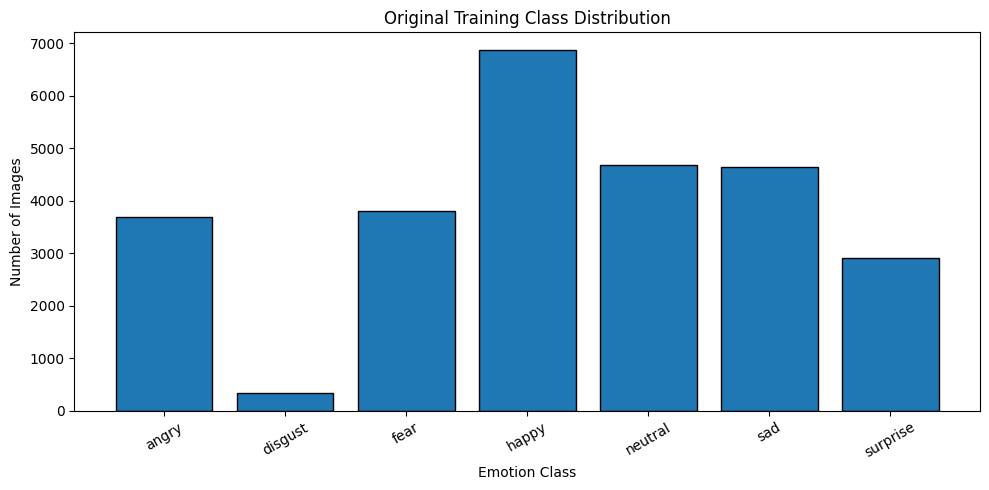

In [ ]:
# Cell 3: Check Original Class Distribution
# This cell counts how many images are available in each original training, validation, and test class.

def is_image_file(filename):
    return filename.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp"))


def count_images_per_class(directory):
    class_counts = {}

    if not os.path.exists(directory):
        raise FileNotFoundError(f"Directory not found: {directory}")

    for class_name in sorted(os.listdir(directory)):
        class_path = os.path.join(directory, class_name)

        if os.path.isdir(class_path):
            image_files = [
                file for file in os.listdir(class_path)
                if is_image_file(file)
            ]
            class_counts[class_name] = len(image_files)

    return class_counts


original_train_counts = count_images_per_class(train_dir)
validation_counts = count_images_per_class(validation_dir)
test_counts = count_images_per_class(test_dir)

original_df = pd.DataFrame({
    "Class": list(original_train_counts.keys()),
    "Train Images": list(original_train_counts.values()),
    "Validation Images": [validation_counts.get(cls, 0) for cls in original_train_counts.keys()],
    "Test Images": [test_counts.get(cls, 0) for cls in original_train_counts.keys()]
})

print("Original dataset distribution:")
print(original_df.to_string(index=False))

plt.figure(figsize=(10, 5))
plt.bar(original_df["Class"], original_df["Train Images"], edgecolor="black")
plt.title("Original Training Class Distribution")
plt.xlabel("Emotion Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### Observation from Class Distribution

The class distribution shows that the dataset is not fully balanced. Some expressions such as `happy`, `neutral`, and `sad` contain more training images, while `disgust` has very few samples compared with other classes.

This imbalance is important because CNN models learn patterns from the available examples. If one class has very few images, the model may not learn its features properly. Therefore, balancing the training data is a useful step before model training.

## Creating Folder Structure for Extra Real Samples

This cell creates separate folders for extra real images for each emotion class. These folders are used only if additional real images are available.

The purpose of this step is to support real-sample balancing. Instead of using synthetic augmentation, this notebook balances the training data by reducing majority classes and adding real images to minority classes where possible.

It is important that these extra images are not taken from the validation or test folders, because that would cause data leakage and make the evaluation unfair.

In [ ]:
# Cell 4: Create Extra Real Sample Folder Structure
# Run this once. Then manually put extra real images into the correct class folders.

class_names = sorted(original_train_counts.keys())

os.makedirs(extra_real_dir, exist_ok=True)

for class_name in class_names:
    os.makedirs(os.path.join(extra_real_dir, class_name), exist_ok=True)

print("Extra real sample folders are ready.")
print("Now add real images into these folders if available:")

for class_name in class_names:
    print(os.path.join(extra_real_dir, class_name))

Extra real sample folders are ready.
Now add real images into these folders if available:
extra_real_samples/angry
extra_real_samples/disgust
extra_real_samples/fear
extra_real_samples/happy
extra_real_samples/neutral
extra_real_samples/sad
extra_real_samples/surprise


## Creating a Balanced Training Dataset Using Real Images

This cell creates a new balanced training folder. The balancing process is performed using real images only.

The main steps are:

1. Majority classes are reduced to a fixed target count.
2. Minority classes are increased using additional real images if available.
3. Images are converted to grayscale.
4. Images are resized to 48 × 48 pixels.
5. Validation and test sets are kept unchanged.

This approach helps reduce the effect of class imbalance while still keeping the evaluation fair. No synthetic data augmentation is used in this main experiment.


Processing class: angry
Skipped image: facial expression classification-20260411T145805Z-3-001 (1) (1)/facial expression classification/train/angry/15395.jpg
Reason: cannot identify image file 'facial expression classification-20260411T145805Z-3-001 (1) (1)/facial expression classification/train/angry/15395.jpg'
Skipped image: facial expression classification-20260411T145805Z-3-001 (1) (1)/facial expression classification/train/angry/18369.jpg
Reason: cannot identify image file 'facial expression classification-20260411T145805Z-3-001 (1) (1)/facial expression classification/train/angry/18369.jpg'
Skipped image: facial expression classification-20260411T145805Z-3-001 (1) (1)/facial expression classification/train/angry/26089.jpg
Reason: cannot identify image file 'facial expression classification-20260411T145805Z-3-001 (1) (1)/facial expression classification/train/angry/26089.jpg'
Skipped image: facial expression classification-20260411T145805Z-3-001 (1) (1)/facial expression classifi

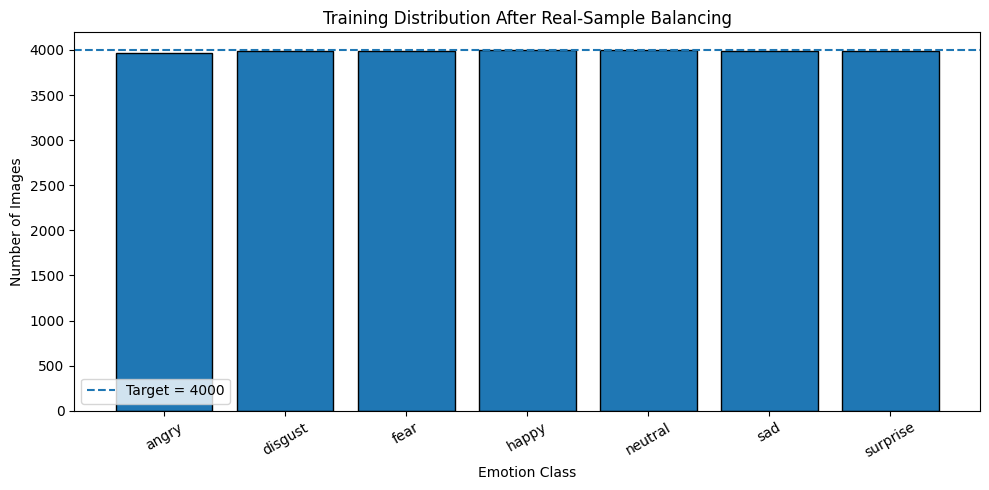

In [ ]:
# Cell 5: Create Balanced Training Dataset Using Real Images Only
# This cell creates a new training folder by:
# 1. Reducing majority classes to the target count.
# 2. Adding real external images to minority classes.
# 3. Keeping validation and test folders unchanged.
# No synthetic augmentation is used.

def list_images(folder):
    if not os.path.exists(folder):
        return []

    return [
        os.path.join(folder, file)
        for file in os.listdir(folder)
        if is_image_file(file)
    ]


def safe_copy_resize_grayscale(source_path, destination_path, image_size=(48, 48)):
    """
    Opens an image safely, converts it to grayscale, resizes it,
    and saves it into the balanced training folder.
    """
    try:
        image = Image.open(source_path).convert("L")
        image = image.resize(image_size)
        image.save(destination_path)
        return True
    except Exception as error:
        print(f"Skipped image: {source_path}")
        print("Reason:", error)
        return False


# Remove old balanced folder if it already exists
if os.path.exists(balanced_train_dir):
    shutil.rmtree(balanced_train_dir)

os.makedirs(balanced_train_dir, exist_ok=True)

balancing_summary = []

for class_name in class_names:
    print(f"\nProcessing class: {class_name}")

    original_class_path = os.path.join(train_dir, class_name)
    extra_class_path = os.path.join(extra_real_dir, class_name)
    output_class_path = os.path.join(balanced_train_dir, class_name)

    os.makedirs(output_class_path, exist_ok=True)

    original_images = list_images(original_class_path)
    extra_images = list_images(extra_class_path)

    original_count = len(original_images)
    extra_count = len(extra_images)

    # If original class has more than target, randomly reduce it.
    if original_count >= TARGET_PER_CLASS:
        selected_original_images = random.sample(original_images, TARGET_PER_CLASS)
        selected_extra_images = []
        action = "Reduced majority class"

    # If original class has fewer than target, add real external images.
    else:
        selected_original_images = original_images.copy()
        required_extra = TARGET_PER_CLASS - original_count

        if extra_count >= required_extra:
            selected_extra_images = random.sample(extra_images, required_extra)
            action = "Added enough real samples"
        else:
            selected_extra_images = extra_images.copy()
            action = "Used available real samples only"

    copied_count = 0

    # Copy original selected images
    for index, source_path in enumerate(selected_original_images):
        destination_path = os.path.join(output_class_path, f"original_{index:05d}.png")

        if safe_copy_resize_grayscale(source_path, destination_path, IMG_SIZE):
            copied_count += 1

    # Copy extra real selected images
    for index, source_path in enumerate(selected_extra_images):
        destination_path = os.path.join(output_class_path, f"extra_real_{index:05d}.png")

        if safe_copy_resize_grayscale(source_path, destination_path, IMG_SIZE):
            copied_count += 1

    balancing_summary.append({
        "Class": class_name,
        "Original Train Count": original_count,
        "Extra Real Images Available": extra_count,
        "Final Balanced Count": copied_count,
        "Target Count": TARGET_PER_CLASS,
        "Action Taken": action
    })

balancing_df = pd.DataFrame(balancing_summary)

print("\nBalancing summary:")
print(balancing_df.to_string(index=False))

plt.figure(figsize=(10, 5))
plt.bar(balancing_df["Class"], balancing_df["Final Balanced Count"], edgecolor="black")
plt.axhline(TARGET_PER_CLASS, linestyle="--", label=f"Target = {TARGET_PER_CLASS}")
plt.title("Training Distribution After Real-Sample Balancing")
plt.xlabel("Emotion Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=30)
plt.legend()
plt.tight_layout()
plt.show()

### Why Real-Sample Balancing Was Used

Real-sample balancing was used because the original training dataset had a large class imbalance. If the model is trained directly on the imbalanced dataset, it may become biased toward classes with more images.

By balancing only the training set, the model receives a more equal number of examples from each emotion class. The validation and test sets are not modified, so the final evaluation still reflects performance on real unseen data.

## Comparing Original and Balanced Training Data

This cell compares the original training distribution with the newly balanced training distribution. The comparison helps verify whether the balancing process worked correctly.

The bar chart clearly shows how the class counts changed after balancing. Majority classes were reduced, while minority classes were improved using real image samples.

This step is useful for explaining the preprocessing and data preparation stage in the final report.

Original vs balanced training distribution:
   Class  Original Train Count  Balanced Train Count
   angry                  3693                  3965
 disgust                   336                  3993
    fear                  3803                  3993
   happy                  6864                  3996
 neutral                  4682                  3996
     sad                  4638                  3993
surprise                  2905                  3993


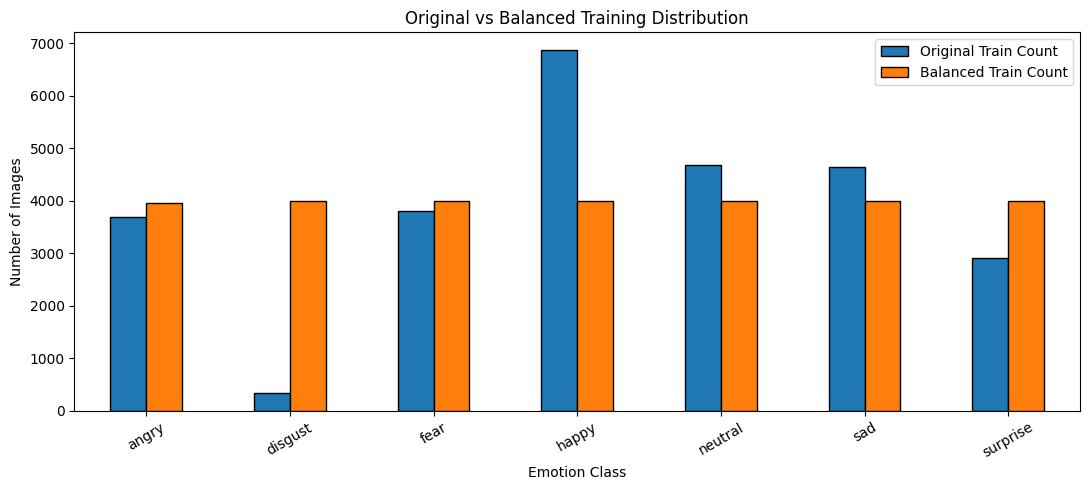

In [ ]:
# Cell 6: Compare Original and Balanced Training Data
# This shows how the new training set differs from the original one.

balanced_counts = count_images_per_class(balanced_train_dir)

comparison_df = pd.DataFrame({
    "Class": class_names,
    "Original Train Count": [original_train_counts.get(cls, 0) for cls in class_names],
    "Balanced Train Count": [balanced_counts.get(cls, 0) for cls in class_names]
})

print("Original vs balanced training distribution:")
print(comparison_df.to_string(index=False))

comparison_df.set_index("Class").plot(
    kind="bar",
    figsize=(11, 5),
    edgecolor="black"
)

plt.title("Original vs Balanced Training Distribution")
plt.xlabel("Emotion Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## Visualizing Sample Images from the Balanced Training Set

This cell displays sample images from the balanced training folder. The purpose is to visually inspect whether the images are readable, correctly resized, and properly converted to grayscale.

Visual inspection is important in image classification tasks because corrupted, unreadable, or wrongly labelled images can negatively affect model training and evaluation.

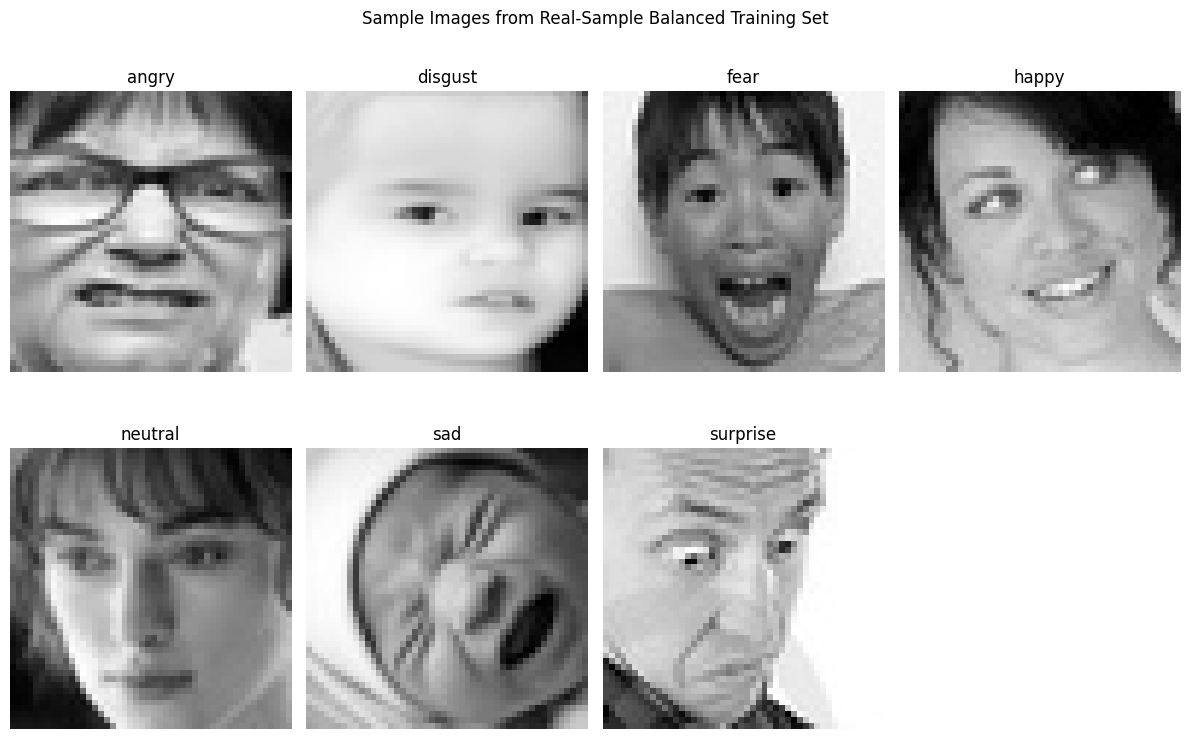

In [ ]:
# Cell 7: Display Sample Images From Balanced Training Set
# This helps verify that the balanced folder contains readable facial expression images.

plt.figure(figsize=(12, 8))

sample_index = 1

for class_name in class_names:
    class_path = os.path.join(balanced_train_dir, class_name)
    images = list_images(class_path)

    if len(images) > 0 and sample_index <= 8:
        selected_image_path = random.choice(images)
        image = Image.open(selected_image_path).convert("L")

        plt.subplot(2, 4, sample_index)
        plt.imshow(image, cmap="gray")
        plt.title(class_name)
        plt.axis("off")

        sample_index += 1

plt.suptitle("Sample Images from Real-Sample Balanced Training Set")
plt.tight_layout()
plt.show()

## Creating Image Data Generators

This cell creates image data generators for training, validation, and testing.

The training generator uses the balanced training folder, while the validation and test generators use the original validation and test folders. All pixel values are normalized by rescaling them from the range 0–255 to 0–1.

For this experiment, no synthetic augmentation is applied. The main preprocessing steps are:

- resizing images to 48 × 48 pixels
- converting images to grayscale
- normalizing pixel values
- loading images in batches

The class mode is set to `categorical` because this is a multi-class classification problem with seven emotion classes.

In [ ]:
# Cell 8: Create Data Generators
# The training generator uses the balanced training folder.
# Validation and test generators use the original validation and test folders.
# No augmentation is used here because this experiment focuses on real-sample balancing.

train_datagen = ImageDataGenerator(
    rescale=1.0 / 255
)

val_test_datagen = ImageDataGenerator(
    rescale=1.0 / 255
)

train_generator = train_datagen.flow_from_directory(
    balanced_train_dir,
    target_size=IMG_SIZE,
    color_mode="grayscale",
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True,
    seed=SEED
)

validation_generator = val_test_datagen.flow_from_directory(
    validation_dir,
    target_size=IMG_SIZE,
    color_mode="grayscale",
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    color_mode="grayscale",
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

CLASS_NAMES = list(train_generator.class_indices.keys())
NUM_CLASSES = len(CLASS_NAMES)

print("Class names:", CLASS_NAMES)
print("Class indices:", train_generator.class_indices)
print("Number of classes:", NUM_CLASSES)
print("Train batches:", len(train_generator))
print("Validation batches:", len(validation_generator))
print("Test batches:", len(test_generator))

Found 27929 images belonging to 7 classes.
Found 7066 images belonging to 7 classes.
Found 1900 images belonging to 7 classes.
Class names: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Class indices: {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}
Number of classes: 7
Train batches: 437
Validation batches: 111
Test batches: 30


## Creating Helper Functions for Training and Evaluation

This cell defines reusable helper functions used throughout the notebook. These functions help to:

- create callback functions
- save the best model during training
- stop training early when validation performance stops improving
- reduce learning rate when validation loss becomes stable
- save training history
- plot training and validation accuracy/loss curves
- evaluate models using accuracy, precision, recall, F1-score, classification report, and confusion matrix

Using helper functions keeps the notebook cleaner and makes the experiments easier to compare.

In [ ]:
# Cell 9: Create Helper Functions for Saving and Evaluation
# These functions save histories, plot curves, and evaluate models consistently.

results_dir = "real_sample_balancing_results"
os.makedirs(results_dir, exist_ok=True)


def get_callbacks(model_name):
    model_folder = os.path.join(results_dir, model_name)
    os.makedirs(model_folder, exist_ok=True)

    checkpoint_path = os.path.join(model_folder, f"{model_name}_best.keras")

    callbacks = [
        ModelCheckpoint(
            filepath=checkpoint_path,
            monitor="val_accuracy",
            save_best_only=True,
            mode="max",
            verbose=1
        ),
        EarlyStopping(
            monitor="val_loss",
            patience=8,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=4,
            min_lr=1e-6,
            verbose=1
        )
    ]

    return callbacks


def save_training_history(history, model_name, training_time):
    model_folder = os.path.join(results_dir, model_name)
    os.makedirs(model_folder, exist_ok=True)

    history_path = os.path.join(model_folder, f"{model_name}_history.json")
    time_path = os.path.join(model_folder, f"{model_name}_training_time.txt")

    with open(history_path, "w") as file:
        json.dump(history.history, file)

    with open(time_path, "w") as file:
        file.write(f"Training time in seconds: {training_time:.2f}")

    print(f"Saved history and training time for {model_name}")


def plot_training_history(history, model_name):
    model_folder = os.path.join(results_dir, model_name)
    os.makedirs(model_folder, exist_ok=True)

    # Accuracy curve
    plt.figure(figsize=(8, 5))
    plt.plot(history.history["accuracy"], label="Training Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
    plt.title(f"{model_name}: Training vs Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(model_folder, f"{model_name}_accuracy_curve.png"), dpi=300)
    plt.show()

    # Loss curve
    plt.figure(figsize=(8, 5))
    plt.plot(history.history["loss"], label="Training Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.title(f"{model_name}: Training vs Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(model_folder, f"{model_name}_loss_curve.png"), dpi=300)
    plt.show()


def evaluate_model(model, generator, model_name):
    model_folder = os.path.join(results_dir, model_name)
    os.makedirs(model_folder, exist_ok=True)

    generator.reset()

    loss, accuracy = model.evaluate(generator, verbose=1)

    predictions = model.predict(generator, verbose=1)
    predicted_classes = np.argmax(predictions, axis=1)
    true_classes = generator.classes

    report = classification_report(
        true_classes,
        predicted_classes,
        target_names=CLASS_NAMES,
        output_dict=True,
        zero_division=0
    )

    report_df = pd.DataFrame(report).transpose()
    report_df.to_csv(os.path.join(model_folder, f"{model_name}_classification_report.csv"))

    print(f"\n{model_name} Test Loss: {loss:.4f}")
    print(f"{model_name} Test Accuracy: {accuracy:.4f}")
    print("\nClassification Report:")
    print(classification_report(true_classes, predicted_classes, target_names=CLASS_NAMES, zero_division=0))

    cm = confusion_matrix(true_classes, predicted_classes)

    fig, ax = plt.subplots(figsize=(8, 8))
    display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
    display.plot(cmap="Blues", xticks_rotation=45, ax=ax)
    plt.title(f"{model_name}: Confusion Matrix")
    plt.tight_layout()
    plt.savefig(os.path.join(model_folder, f"{model_name}_confusion_matrix.png"), dpi=300)
    plt.show()

    return {
        "Model": model_name,
        "Test Loss": loss,
        "Test Accuracy": accuracy,
        "Macro F1": report["macro avg"]["f1-score"],
        "Weighted F1": report["weighted avg"]["f1-score"]
    }

## Building the Baseline CNN Model

This cell builds the baseline Convolutional Neural Network from scratch. The baseline model is designed as a simple reference model so that later models can be compared against it.

The architecture includes:

- three convolutional layers
- three max-pooling layers
- three fully connected dense layers
- one softmax output layer for seven-class classification

ReLU activation is used in the hidden layers because it helps the model learn non-linear patterns. The final layer uses softmax because the task is multi-class classification.

In [ ]:
# Cell 10: Build Baseline CNN Model
# This baseline follows the requirement:
# 3 convolutional layers, each followed by pooling,
# then 3 fully connected layers and an output layer.

def build_baseline_cnn(input_shape=(48, 48, 1), num_classes=7):
    model = Sequential(name="Baseline_CNN_Real_Balancing")

    model.add(Conv2D(32, (3, 3), activation="relu", padding="same", input_shape=input_shape))
    model.add(MaxPooling2D((2, 2)))

    model.add(Conv2D(64, (3, 3), activation="relu", padding="same"))
    model.add(MaxPooling2D((2, 2)))

    model.add(Conv2D(128, (3, 3), activation="relu", padding="same"))
    model.add(MaxPooling2D((2, 2)))

    model.add(Flatten())

    model.add(Dense(256, activation="relu"))
    model.add(Dense(128, activation="relu"))
    model.add(Dense(64, activation="relu"))

    model.add(Dense(num_classes, activation="softmax"))

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


baseline_model = build_baseline_cnn(
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 1),
    num_classes=NUM_CLASSES
)

baseline_model.summary()

/home/ankush/tf/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1778297035.188800    3827 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1763 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Model: "Baseline_CNN_Real_Balancing"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,314,183 (5.01 MB)

 Trainable params: 1,314,183 (5.01 MB)

 Non-trainable params: 0 (0.00 B)

### Baseline Model Summary Interpretation

The baseline CNN starts with a small number of filters and gradually increases the filters in deeper layers. This allows the model to learn simple features such as edges in the early layers and more complex facial patterns in later layers.

Max-pooling is used after each convolutional layer to reduce the spatial size of the feature maps and keep the most important information. After the convolutional part, the feature maps are flattened and passed through three dense layers for classification.

The output layer has seven neurons because the dataset contains seven facial expression classes.

## Training the Baseline CNN Model

This cell trains the baseline CNN model using the balanced training data and validates it on the original validation set.

Callbacks are used during training:

- `ModelCheckpoint` saves the best model
- `EarlyStopping` stops training when validation loss does not improve
- `ReduceLROnPlateau` reduces the learning rate when learning becomes slow

Training and validation accuracy/loss curves are plotted after training. These curves help identify whether the model is learning properly, overfitting, or underfitting.

Epoch 1/50


I0000 00:00:1778297121.044411    3827 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
I0000 00:00:1778297122.422585    4406 service.cc:153] XLA service 0x75472c037780 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778297122.422627    4406 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3050 Laptop GPU, Compute Capability 8.6 (Driver: 13.1.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.22.0)
I0000 00:00:1778297122.523178    4406 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1778297122.883621    4406 cuda_dnn.cc:461] Loaded cuDNN version 92200
I0000 00:00:1778297122.927648    4406 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2560__.45
I0000 00:00:1778297125.430148    4406 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe th

  1/437 ━━━━━━━━━━━━━━━━━━━━ 1:34:35 13s/step - accuracy: 0.2656 - loss: 1.9414

I0000 00:00:1778297133.887842    4406 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


306/437 ━━━━━━━━━━━━━━━━━━━━ 25s 195ms/step - accuracy: 0.1986 - loss: 1.8907

I0000 00:00:1778297193.961964    4408 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2560__.45


437/437 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step - accuracy: 0.2273 - loss: 1.8475
Epoch 1: val_accuracy improved from None to 0.41410, saving model to real_sample_balancing_results/baseline_cnn_real_balancing/baseline_cnn_real_balancing_best.keras

Epoch 1: finished saving model to real_sample_balancing_results/baseline_cnn_real_balancing/baseline_cnn_real_balancing_best.keras
437/437 ━━━━━━━━━━━━━━━━━━━━ 141s 294ms/step - accuracy: 0.3142 - loss: 1.7113 - val_accuracy: 0.4141 - val_loss: 1.5274 - learning_rate: 0.0010
Epoch 2/50
437/437 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step - accuracy: 0.4500 - loss: 1.4506
Epoch 2: val_accuracy improved from 0.41410 to 0.46108, saving model to real_sample_balancing_results/baseline_cnn_real_balancing/baseline_cnn_real_balancing_best.keras

Epoch 2: finished saving model to real_sample_balancing_results/baseline_cnn_real_balancing/baseline_cnn_real_balancing_best.keras
437/437 ━━━━━━━━━━━━━━━━━━━━ 113s 259ms/step - accuracy: 0.4609 - loss: 1.4211 - val_accura

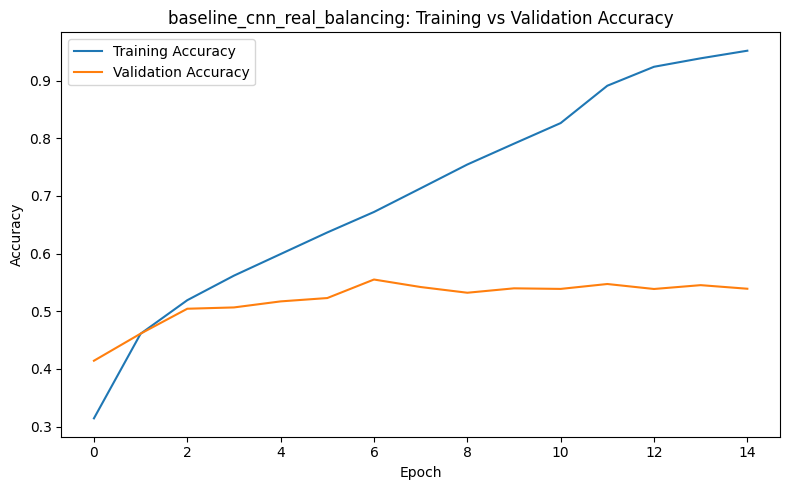

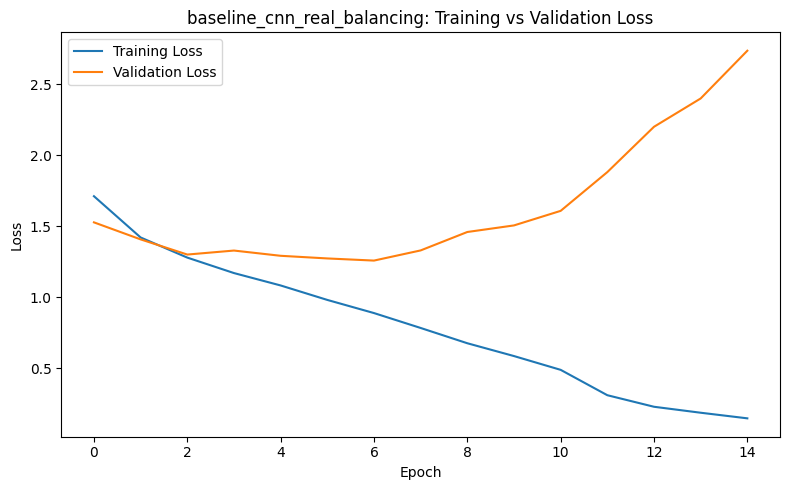

Baseline CNN training time: 1699.89 seconds


In [ ]:
# Cell 11: Train Baseline CNN Model
# The best baseline model is saved automatically using ModelCheckpoint.

start_time = time.time()

baseline_history = baseline_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=50,
    callbacks=get_callbacks("baseline_cnn_real_balancing"),
    verbose=1
)

baseline_training_time = time.time() - start_time

save_training_history(
    history=baseline_history,
    model_name="baseline_cnn_real_balancing",
    training_time=baseline_training_time
)

plot_training_history(
    history=baseline_history,
    model_name="baseline_cnn_real_balancing"
)

print(f"Baseline CNN training time: {baseline_training_time:.2f} seconds")

## Evaluating the Baseline CNN Model

This cell loads the best saved baseline model and evaluates it on the test set. The test set was not used during training, so it provides a fair estimate of the model’s performance on unseen images.

The model is evaluated using:

- test loss
- test accuracy
- precision
- recall
- F1-score
- classification report
- confusion matrix

The baseline result is used as the reference point for comparing deeper CNN models and transfer learning models.

29/30 ━━━━━━━━━━━━━━━━━━━━ 0s 269ms/step - accuracy: 0.4355 - loss: 1.6100

I0000 00:00:1778298864.408810    4406 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1778298864.964694    6331 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_12', 196 bytes spill stores, 196 bytes spill loads



30/30 ━━━━━━━━━━━━━━━━━━━━ 12s 359ms/step - accuracy: 0.5026 - loss: 1.4224
30/30 ━━━━━━━━━━━━━━━━━━━━ 8s 252ms/step

baseline_cnn_real_balancing Test Loss: 1.4224
baseline_cnn_real_balancing Test Accuracy: 0.5026

Classification Report:
              precision    recall  f1-score   support

       angry       0.45      0.41      0.43       300
     disgust       0.38      0.38      0.38       100
        fear       0.48      0.26      0.33       300
       happy       0.62      0.71      0.66       300
     neutral       0.46      0.56      0.50       300
         sad       0.36      0.40      0.38       300
    surprise       0.68      0.72      0.70       300

    accuracy                           0.50      1900
   macro avg       0.49      0.49      0.48      1900
weighted avg       0.50      0.50      0.49      1900



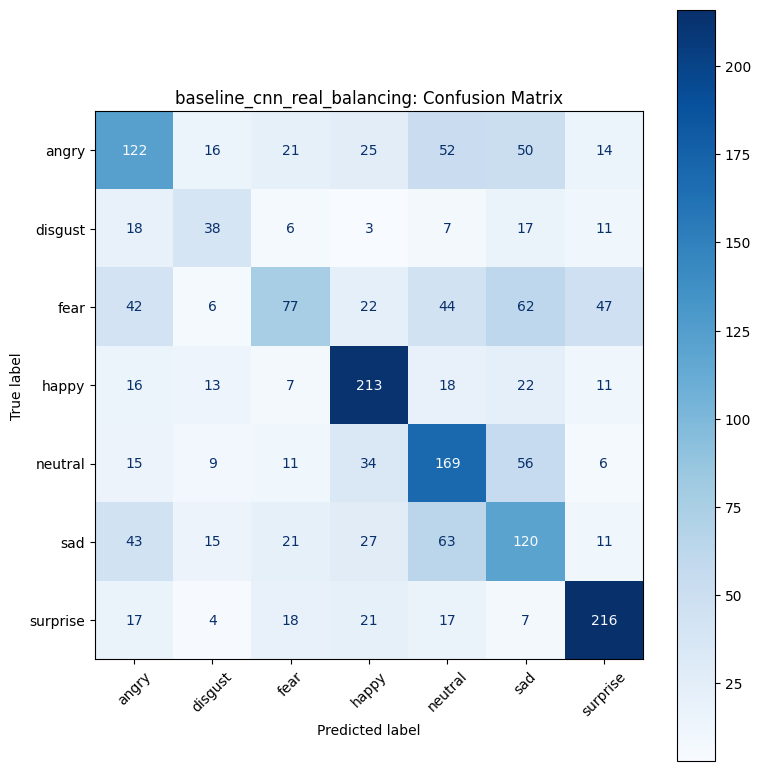

{'Model': 'baseline_cnn_real_balancing',
 'Test Loss': 1.4223949909210205,
 'Test Accuracy': 0.5026316046714783,
 'Macro F1': 0.483255021088193,
 'Weighted F1': 0.49432297565154815}

In [ ]:
# Cell 12: Evaluate Best Baseline CNN Model
# This loads the best saved baseline model and evaluates it on the test set.

best_baseline_path = os.path.join(
    results_dir,
    "baseline_cnn_real_balancing",
    "baseline_cnn_real_balancing_best.keras"
)

best_baseline_model = load_model(best_baseline_path)

baseline_result = evaluate_model(
    model=best_baseline_model,
    generator=test_generator,
    model_name="baseline_cnn_real_balancing"
)

baseline_result

## Building the Deeper CNN Model with Batch Normalization and Dropout

This cell builds a deeper CNN model from scratch. Compared with the baseline model, this model has more convolutional layers and more filters, allowing it to learn more detailed facial expression features.

The model uses:

- multiple convolutional layers
- max-pooling layers
- Batch Normalization
- Dropout
- dense layers
- softmax output layer

Batch Normalization helps stabilize training, while Dropout reduces overfitting by randomly disabling some neurons during training. This model is trained using the Adam optimizer.

In [ ]:
# Cell 13: Build Deeper CNN With Batch Normalization and Dropout
# This model is deeper than the baseline and includes regularization.
# Batch Normalization stabilizes learning, while Dropout helps reduce overfitting.

def build_deeper_cnn_adam(input_shape=(48, 48, 1), num_classes=7):
    model = Sequential(name="Deeper_CNN_Adam_Real_Balancing")

    model.add(Conv2D(32, (3, 3), activation="relu", padding="same", input_shape=input_shape))
    model.add(BatchNormalization())
    model.add(Conv2D(32, (3, 3), activation="relu", padding="same"))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2, 2)))
    model.add(Dropout(0.25))

    model.add(Conv2D(64, (3, 3), activation="relu", padding="same"))
    model.add(BatchNormalization())
    model.add(Conv2D(64, (3, 3), activation="relu", padding="same"))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2, 2)))
    model.add(Dropout(0.30))

    model.add(Conv2D(128, (3, 3), activation="relu", padding="same"))
    model.add(BatchNormalization())
    model.add(Conv2D(128, (3, 3), activation="relu", padding="same"))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2, 2)))
    model.add(Dropout(0.35))

    model.add(Flatten())

    model.add(Dense(256, activation="relu"))
    model.add(BatchNormalization())
    model.add(Dropout(0.50))

    model.add(Dense(128, activation="relu"))
    model.add(BatchNormalization())
    model.add(Dropout(0.40))

    model.add(Dense(64, activation="relu"))

    model.add(Dense(num_classes, activation="softmax"))

    model.compile(
        optimizer=Adam(learning_rate=0.0005),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


deeper_adam_model = build_deeper_cnn_adam(
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 1),
    num_classes=NUM_CLASSES
)

deeper_adam_model.summary()

/home/ankush/tf/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Deeper_CNN_Adam_Real_Balancing"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,511,271 (5.77 MB)

 Trainable params: 1,509,607 (5.76 MB)

 Non-trainable params: 1,664 (6.50 KB)

### Deeper CNN Summary Interpretation

The deeper CNN has more convolutional layers than the baseline model, which increases its ability to learn complex facial features. Since facial expressions can be subtle and similar across classes, a deeper architecture can help capture more useful patterns.

Batch Normalization is added to make training more stable, and Dropout is used to reduce overfitting. This makes the model more suitable for learning from a balanced but still challenging facial expression dataset.

## Training the Deeper CNN with Adam Optimizer

This cell trains the deeper CNN model using the Adam optimizer. Adam is commonly used in deep learning because it adjusts the learning rate automatically during training and usually converges faster than basic gradient descent methods.

The same balanced training data and original validation data are used. This makes the comparison between the baseline CNN and the deeper CNN fair.

The training time is also recorded so that model performance can be compared not only by accuracy but also by computational cost.

Epoch 1/60


I0000 00:00:1778299096.132506    4407 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_46171__.99
I0000 00:00:1778299096.806760    4407 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1778299098.748798    4407 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1778299099.605927    4407 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


119/437 ━━━━━━━━━━━━━━━━━━━━ 1:00 190ms/step - accuracy: 0.1750 - loss: 2.2790

I0000 00:00:1778299132.055847    4405 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_46171__.99


437/437 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step - accuracy: 0.2080 - loss: 2.1131
Epoch 1: val_accuracy improved from None to 0.20478, saving model to real_sample_balancing_results/deeper_cnn_adam_real_balancing/deeper_cnn_adam_real_balancing_best.keras

Epoch 1: finished saving model to real_sample_balancing_results/deeper_cnn_adam_real_balancing/deeper_cnn_adam_real_balancing_best.keras
437/437 ━━━━━━━━━━━━━━━━━━━━ 145s 288ms/step - accuracy: 0.2490 - loss: 1.9566 - val_accuracy: 0.2048 - val_loss: 1.9421 - learning_rate: 5.0000e-04
Epoch 2/60
437/437 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step - accuracy: 0.3419 - loss: 1.6852
Epoch 2: val_accuracy improved from 0.20478 to 0.26323, saving model to real_sample_balancing_results/deeper_cnn_adam_real_balancing/deeper_cnn_adam_real_balancing_best.keras

Epoch 2: finished saving model to real_sample_balancing_results/deeper_cnn_adam_real_balancing/deeper_cnn_adam_real_balancing_best.keras
437/437 ━━━━━━━━━━━━━━━━━━━━ 114s 261ms/step - accuracy: 0.3608

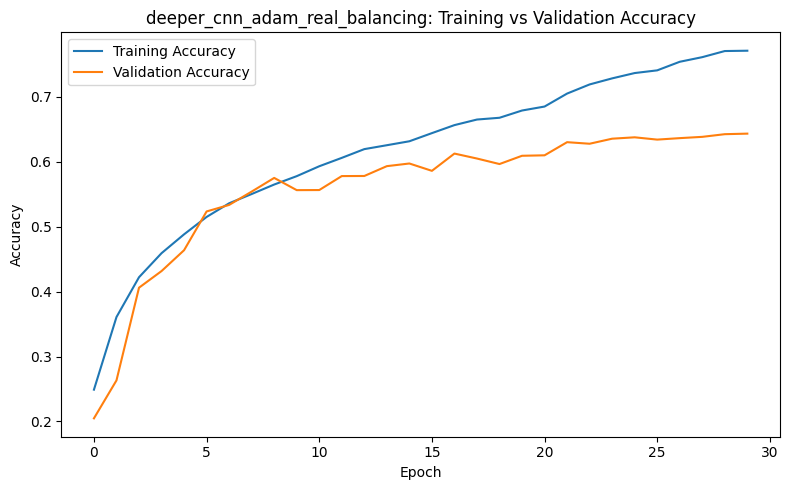

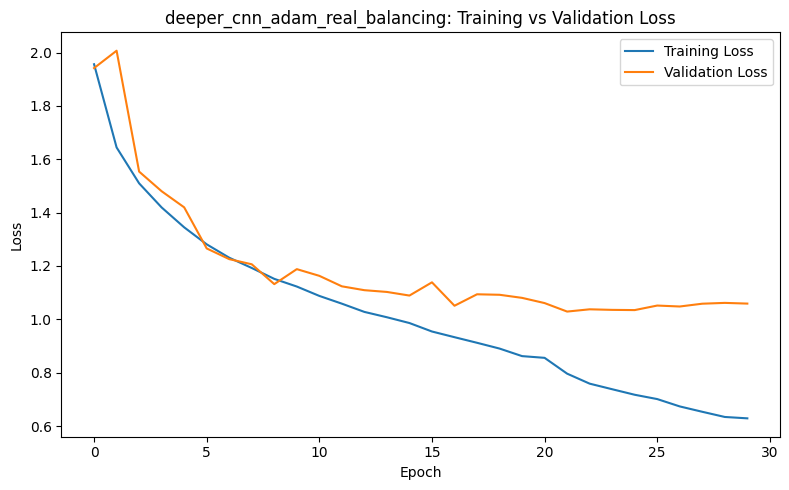

Deeper CNN Adam training time: 3331.05 seconds


In [ ]:
# Cell 14: Train Deeper CNN With Adam
# This experiment checks whether a deeper regularized CNN improves performance.

start_time = time.time()

deeper_adam_history = deeper_adam_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=60,
    callbacks=get_callbacks("deeper_cnn_adam_real_balancing"),
    verbose=1
)

deeper_adam_training_time = time.time() - start_time

save_training_history(
    history=deeper_adam_history,
    model_name="deeper_cnn_adam_real_balancing",
    training_time=deeper_adam_training_time
)

plot_training_history(
    history=deeper_adam_history,
    model_name="deeper_cnn_adam_real_balancing"
)

print(f"Deeper CNN Adam training time: {deeper_adam_training_time:.2f} seconds")

## Evaluating the Deeper CNN with Adam Optimizer

This cell evaluates the best saved deeper CNN model trained with Adam on the test set.

The evaluation results are compared with the baseline CNN to check whether increasing the number of layers and adding regularization improved performance. The confusion matrix and classification report also help identify which emotion classes are predicted well and which classes are still difficult for the model.

29/30 ━━━━━━━━━━━━━━━━━━━━ 0s 280ms/step - accuracy: 0.5600 - loss: 1.3824

I0000 00:00:1778302482.690472    4406 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


30/30 ━━━━━━━━━━━━━━━━━━━━ 14s 365ms/step - accuracy: 0.6021 - loss: 1.2434
30/30 ━━━━━━━━━━━━━━━━━━━━ 9s 272ms/step

deeper_cnn_adam_real_balancing Test Loss: 1.2434
deeper_cnn_adam_real_balancing Test Accuracy: 0.6021

Classification Report:
              precision    recall  f1-score   support

       angry       0.54      0.57      0.55       300
     disgust       0.74      0.37      0.49       100
        fear       0.48      0.42      0.45       300
       happy       0.75      0.81      0.78       300
     neutral       0.55      0.64      0.59       300
         sad       0.45      0.51      0.48       300
    surprise       0.83      0.75      0.78       300

    accuracy                           0.60      1900
   macro avg       0.62      0.58      0.59      1900
weighted avg       0.61      0.60      0.60      1900



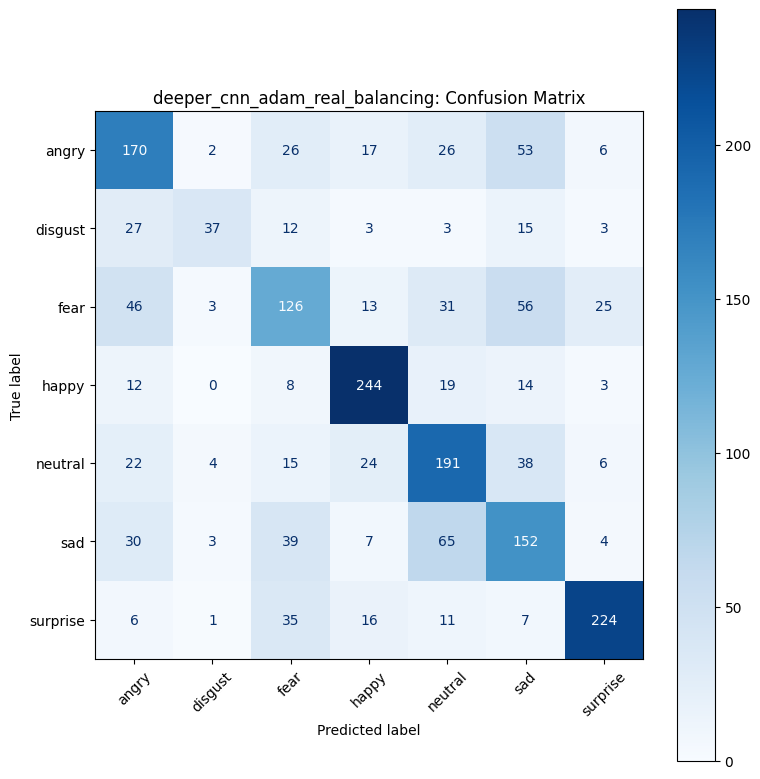

{'Model': 'deeper_cnn_adam_real_balancing',
 'Test Loss': 1.2433735132217407,
 'Test Accuracy': 0.6021052598953247,
 'Macro F1': 0.5905559443448176,
 'Weighted F1': 0.6007899033986582}

In [ ]:
# Cell 15: Evaluate Best Deeper CNN With Adam

best_deeper_adam_path = os.path.join(
    results_dir,
    "deeper_cnn_adam_real_balancing",
    "deeper_cnn_adam_real_balancing_best.keras"
)

best_deeper_adam_model = load_model(best_deeper_adam_path)

deeper_adam_result = evaluate_model(
    model=best_deeper_adam_model,
    generator=test_generator,
    model_name="deeper_cnn_adam_real_balancing"
)

deeper_adam_result

## Building the Deeper CNN Model with SGD Optimizer

This cell builds the same deeper CNN architecture again, but this time it is compiled with the SGD optimizer.

The purpose of this experiment is to compare the effect of different optimizers using the same model structure. By keeping the architecture same and changing only the optimizer, the comparison becomes fair and easier to explain.

In [ ]:
# Cell 16: Build Deeper CNN With SGD Optimizer
# Same architecture as the Adam model, but optimizer is changed to SGD.
# This is required for optimizer comparison.

def build_deeper_cnn_sgd(input_shape=(48, 48, 1), num_classes=7):
    model = Sequential(name="Deeper_CNN_SGD_Real_Balancing")

    model.add(Conv2D(32, (3, 3), activation="relu", padding="same", input_shape=input_shape))
    model.add(BatchNormalization())
    model.add(Conv2D(32, (3, 3), activation="relu", padding="same"))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2, 2)))
    model.add(Dropout(0.25))

    model.add(Conv2D(64, (3, 3), activation="relu", padding="same"))
    model.add(BatchNormalization())
    model.add(Conv2D(64, (3, 3), activation="relu", padding="same"))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2, 2)))
    model.add(Dropout(0.30))

    model.add(Conv2D(128, (3, 3), activation="relu", padding="same"))
    model.add(BatchNormalization())
    model.add(Conv2D(128, (3, 3), activation="relu", padding="same"))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2, 2)))
    model.add(Dropout(0.35))

    model.add(Flatten())

    model.add(Dense(256, activation="relu"))
    model.add(BatchNormalization())
    model.add(Dropout(0.50))

    model.add(Dense(128, activation="relu"))
    model.add(BatchNormalization())
    model.add(Dropout(0.40))

    model.add(Dense(64, activation="relu"))

    model.add(Dense(num_classes, activation="softmax"))

    model.compile(
        optimizer=SGD(learning_rate=0.01, momentum=0.9),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


deeper_sgd_model = build_deeper_cnn_sgd(
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 1),
    num_classes=NUM_CLASSES
)

deeper_sgd_model.summary()

/home/ankush/tf/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Deeper_CNN_SGD_Real_Balancing"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,511,271 (5.77 MB)

 Trainable params: 1,509,607 (5.76 MB)

 Non-trainable params: 1,664 (6.50 KB)

## Training the Deeper CNN with SGD Optimizer

This cell trains the deeper CNN model using SGD with momentum. SGD is a traditional optimizer that updates model weights step by step using gradient information.

Compared with Adam, SGD may train more slowly, but it can sometimes generalize well depending on the dataset and learning rate. Training this model helps analyze how optimizer choice affects convergence speed and final performance.

Epoch 1/60


I0000 00:00:1778302617.196370    4406 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_128145__.99
I0000 00:00:1778302617.374703    4406 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1778302618.661057    4406 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


 58/437 ━━━━━━━━━━━━━━━━━━━━ 1:11 188ms/step - accuracy: 0.1501 - loss: 2.4359

I0000 00:00:1778302637.048636    4406 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_128145__.99
I0000 00:00:1778302637.329949    9763 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_1_12', 12 bytes spill stores, 12 bytes spill loads



437/437 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step - accuracy: 0.1915 - loss: 2.0828
Epoch 1: val_accuracy improved from None to 0.16077, saving model to real_sample_balancing_results/deeper_cnn_sgd_real_balancing/deeper_cnn_sgd_real_balancing_best.keras

Epoch 1: finished saving model to real_sample_balancing_results/deeper_cnn_sgd_real_balancing/deeper_cnn_sgd_real_balancing_best.keras
437/437 ━━━━━━━━━━━━━━━━━━━━ 133s 275ms/step - accuracy: 0.2256 - loss: 1.9367 - val_accuracy: 0.1608 - val_loss: 1.9693 - learning_rate: 0.0100
Epoch 2/60
437/437 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step - accuracy: 0.3120 - loss: 1.7419
Epoch 2: val_accuracy improved from 0.16077 to 0.32805, saving model to real_sample_balancing_results/deeper_cnn_sgd_real_balancing/deeper_cnn_sgd_real_balancing_best.keras

Epoch 2: finished saving model to real_sample_balancing_results/deeper_cnn_sgd_real_balancing/deeper_cnn_sgd_real_balancing_best.keras
437/437 ━━━━━━━━━━━━━━━━━━━━ 109s 249ms/step - accuracy: 0.3327 - loss: 1.7

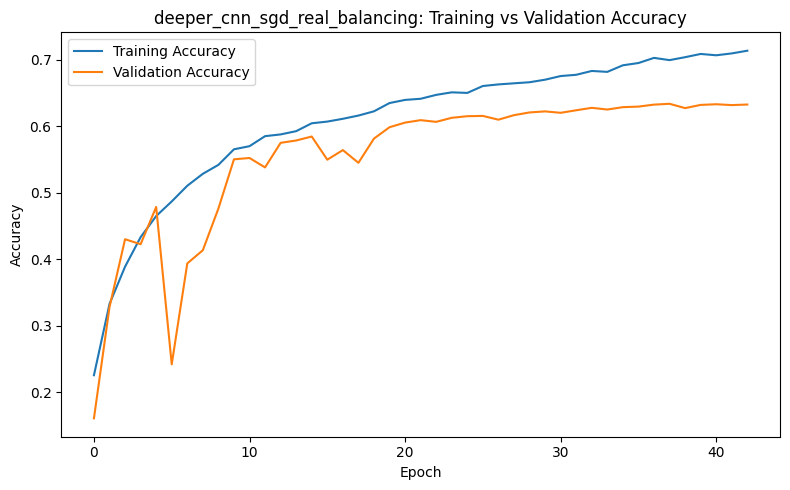

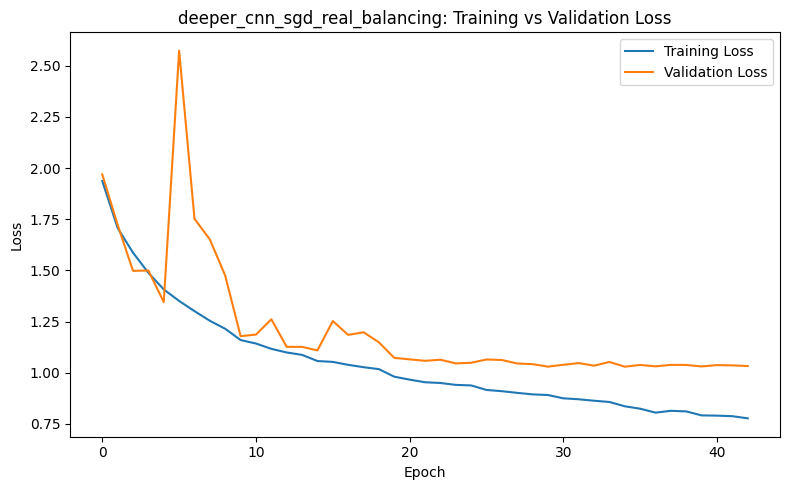

Deeper CNN SGD training time: 4745.15 seconds


In [ ]:
# Cell 17: Train Deeper CNN With SGD
# This model is trained to compare SGD against Adam.

start_time = time.time()

deeper_sgd_history = deeper_sgd_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=60,
    callbacks=get_callbacks("deeper_cnn_sgd_real_balancing"),
    verbose=1
)

deeper_sgd_training_time = time.time() - start_time

save_training_history(
    history=deeper_sgd_history,
    model_name="deeper_cnn_sgd_real_balancing",
    training_time=deeper_sgd_training_time
)

plot_training_history(
    history=deeper_sgd_history,
    model_name="deeper_cnn_sgd_real_balancing"
)

print(f"Deeper CNN SGD training time: {deeper_sgd_training_time:.2f} seconds")

## Evaluating the Deeper CNN with SGD Optimizer

This cell evaluates the best saved SGD-based deeper CNN model on the test set.

The results are compared with the Adam-based deeper CNN to understand which optimizer performs better for this facial expression classification task. Accuracy, loss, macro F1-score, weighted F1-score, classification report, and confusion matrix are used for comparison.

30/30 ━━━━━━━━━━━━━━━━━━━━ 12s 304ms/step - accuracy: 0.5905 - loss: 1.1858
30/30 ━━━━━━━━━━━━━━━━━━━━ 9s 268ms/step

deeper_cnn_sgd_real_balancing Test Loss: 1.1858
deeper_cnn_sgd_real_balancing Test Accuracy: 0.5905

Classification Report:
              precision    recall  f1-score   support

       angry       0.52      0.53      0.52       300
     disgust       0.65      0.37      0.47       100
        fear       0.52      0.37      0.44       300
       happy       0.76      0.79      0.78       300
     neutral       0.52      0.64      0.58       300
         sad       0.44      0.49      0.46       300
    surprise       0.77      0.79      0.78       300

    accuracy                           0.59      1900
   macro avg       0.60      0.57      0.57      1900
weighted avg       0.59      0.59      0.59      1900



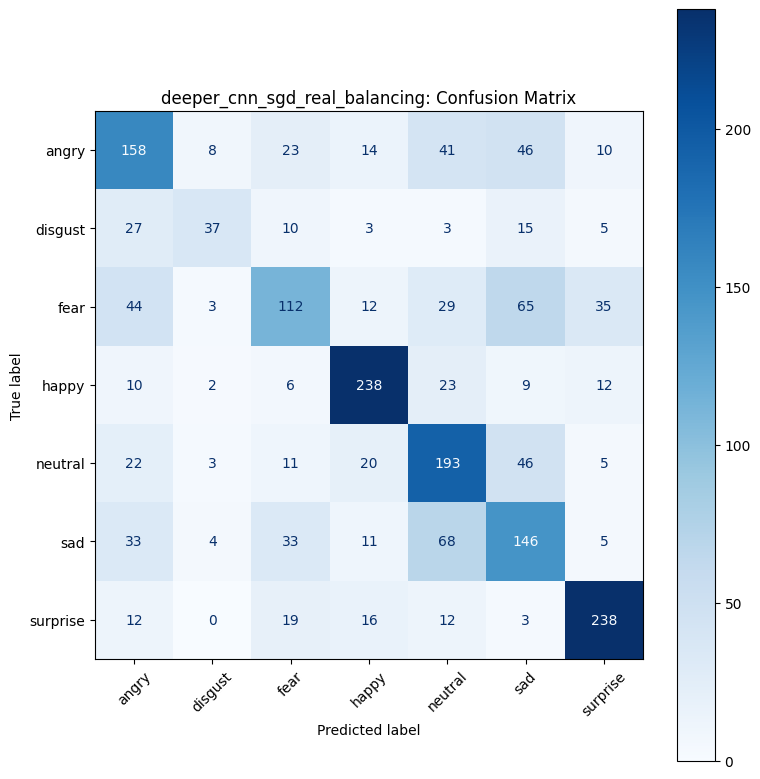

{'Model': 'deeper_cnn_sgd_real_balancing',
 'Test Loss': 1.1857765913009644,
 'Test Accuracy': 0.5905263423919678,
 'Macro F1': 0.5749474557475363,
 'Weighted F1': 0.5858537584980311}

In [ ]:
# Cell 18: Evaluate Best Deeper CNN With SGD

best_deeper_sgd_path = os.path.join(
    results_dir,
    "deeper_cnn_sgd_real_balancing",
    "deeper_cnn_sgd_real_balancing_best.keras"
)

best_deeper_sgd_model = load_model(best_deeper_sgd_path)

deeper_sgd_result = evaluate_model(
    model=best_deeper_sgd_model,
    generator=test_generator,
    model_name="deeper_cnn_sgd_real_balancing"
)

deeper_sgd_result

## Building the Ablation Model Without Dropout

This cell builds an ablation version of the deeper CNN model by removing Dropout layers.

An ablation study is used to understand the importance of a specific model component. In this case, Dropout is removed to check whether it was helping the model generalize better.

The rest of the architecture is kept similar so that the effect of removing Dropout can be analyzed more fairly.

In [ ]:
# Cell 19: Build Ablation Model Without Dropout
# This model removes Dropout from the deeper CNN.
# The purpose is to check how much Dropout contributed to generalization.

def build_ablation_no_dropout(input_shape=(48, 48, 1), num_classes=7):
    model = Sequential(name="Ablation_No_Dropout_Real_Balancing")

    model.add(Conv2D(32, (3, 3), activation="relu", padding="same", input_shape=input_shape))
    model.add(BatchNormalization())
    model.add(Conv2D(32, (3, 3), activation="relu", padding="same"))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2, 2)))

    model.add(Conv2D(64, (3, 3), activation="relu", padding="same"))
    model.add(BatchNormalization())
    model.add(Conv2D(64, (3, 3), activation="relu", padding="same"))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2, 2)))

    model.add(Conv2D(128, (3, 3), activation="relu", padding="same"))
    model.add(BatchNormalization())
    model.add(Conv2D(128, (3, 3), activation="relu", padding="same"))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2, 2)))

    model.add(Flatten())

    model.add(Dense(256, activation="relu"))
    model.add(BatchNormalization())

    model.add(Dense(128, activation="relu"))
    model.add(BatchNormalization())

    model.add(Dense(64, activation="relu"))

    model.add(Dense(num_classes, activation="softmax"))

    model.compile(
        optimizer=Adam(learning_rate=0.0005),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


ablation_model = build_ablation_no_dropout(
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 1),
    num_classes=NUM_CLASSES
)

ablation_model.summary()

/home/ankush/tf/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Ablation_No_Dropout_Real_Balancing"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │         8,25

 Total params: 1,511,271 (5.77 MB)

 Trainable params: 1,509,607 (5.76 MB)

 Non-trainable params: 1,664 (6.50 KB)

## Training the Ablation Model Without Dropout

This cell trains the ablation model without Dropout. The purpose is to observe how the model behaves when one regularization technique is removed.

If the ablation model performs worse than the regularized deeper CNN, it suggests that Dropout helped reduce overfitting and improved generalization.

Epoch 1/60


I0000 00:00:1778307554.380135    4406 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_240582__.94


117/437 ━━━━━━━━━━━━━━━━━━━━ 1:00 189ms/step - accuracy: 0.2623 - loss: 1.9933

I0000 00:00:1778307582.075596    4406 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_240582__.94


437/437 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step - accuracy: 0.3351 - loss: 1.7659
Epoch 1: val_accuracy improved from None to 0.17705, saving model to real_sample_balancing_results/ablation_no_dropout_real_balancing/ablation_no_dropout_real_balancing_best.keras

Epoch 1: finished saving model to real_sample_balancing_results/ablation_no_dropout_real_balancing/ablation_no_dropout_real_balancing_best.keras
437/437 ━━━━━━━━━━━━━━━━━━━━ 127s 270ms/step - accuracy: 0.3953 - loss: 1.5892 - val_accuracy: 0.1770 - val_loss: 2.1911 - learning_rate: 5.0000e-04
Epoch 2/60
437/437 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step - accuracy: 0.5219 - loss: 1.2737
Epoch 2: val_accuracy improved from 0.17705 to 0.46519, saving model to real_sample_balancing_results/ablation_no_dropout_real_balancing/ablation_no_dropout_real_balancing_best.keras

Epoch 2: finished saving model to real_sample_balancing_results/ablation_no_dropout_real_balancing/ablation_no_dropout_real_balancing_best.keras
437/437 ━━━━━━━━━━━━━━━━━━━━ 11

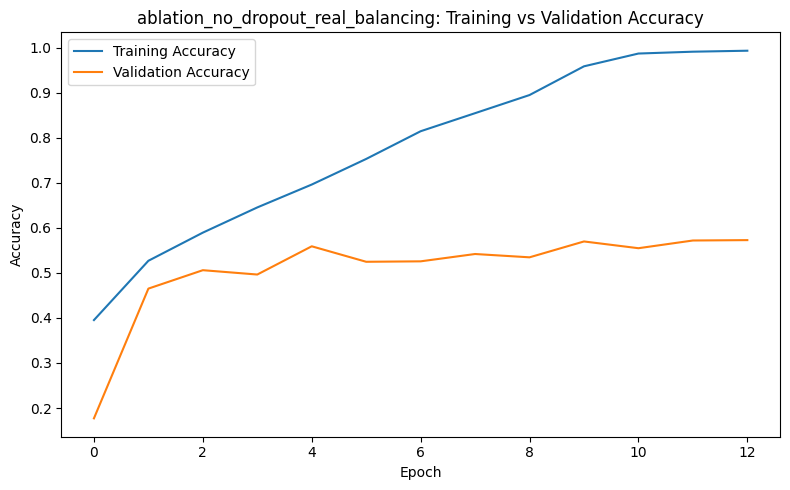

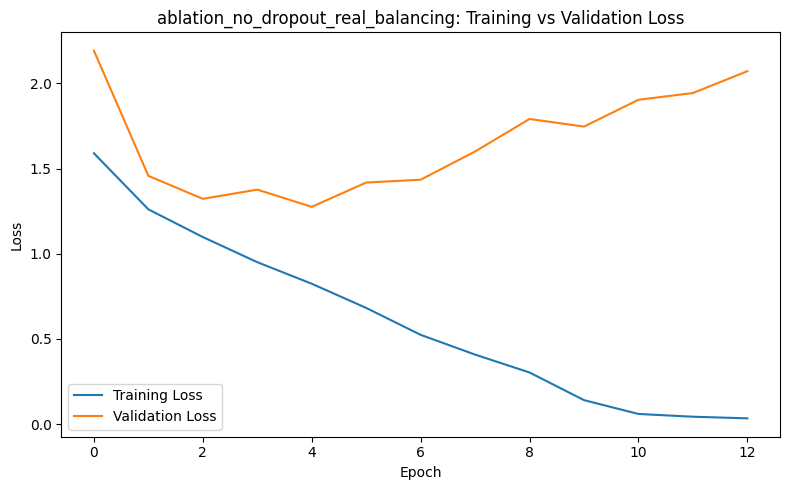

Ablation model training time: 1472.58 seconds


In [ ]:
# Cell 20: Train Ablation Model Without Dropout
# Compare this result with the deeper CNN using Dropout.

start_time = time.time()

ablation_history = ablation_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=60,
    callbacks=get_callbacks("ablation_no_dropout_real_balancing"),
    verbose=1
)

ablation_training_time = time.time() - start_time

save_training_history(
    history=ablation_history,
    model_name="ablation_no_dropout_real_balancing",
    training_time=ablation_training_time
)

plot_training_history(
    history=ablation_history,
    model_name="ablation_no_dropout_real_balancing"
)

print(f"Ablation model training time: {ablation_training_time:.2f} seconds")

## Evaluating the Ablation Model

This cell evaluates the ablation model on the same test set used for the other models.

The results are compared with the deeper CNN model that used Dropout. This helps explain the role of Dropout in improving model performance and controlling overfitting.

30/30 ━━━━━━━━━━━━━━━━━━━━ 10s 282ms/step - accuracy: 0.5479 - loss: 2.3270
30/30 ━━━━━━━━━━━━━━━━━━━━ 11s 262ms/step

ablation_no_dropout_real_balancing Test Loss: 2.3270
ablation_no_dropout_real_balancing Test Accuracy: 0.5479

Classification Report:
              precision    recall  f1-score   support

       angry       0.45      0.50      0.47       300
     disgust       0.75      0.39      0.51       100
        fear       0.45      0.47      0.46       300
       happy       0.77      0.67      0.72       300
     neutral       0.46      0.59      0.52       300
         sad       0.43      0.36      0.39       300
    surprise       0.75      0.75      0.75       300

    accuracy                           0.55      1900
   macro avg       0.58      0.53      0.55      1900
weighted avg       0.56      0.55      0.55      1900



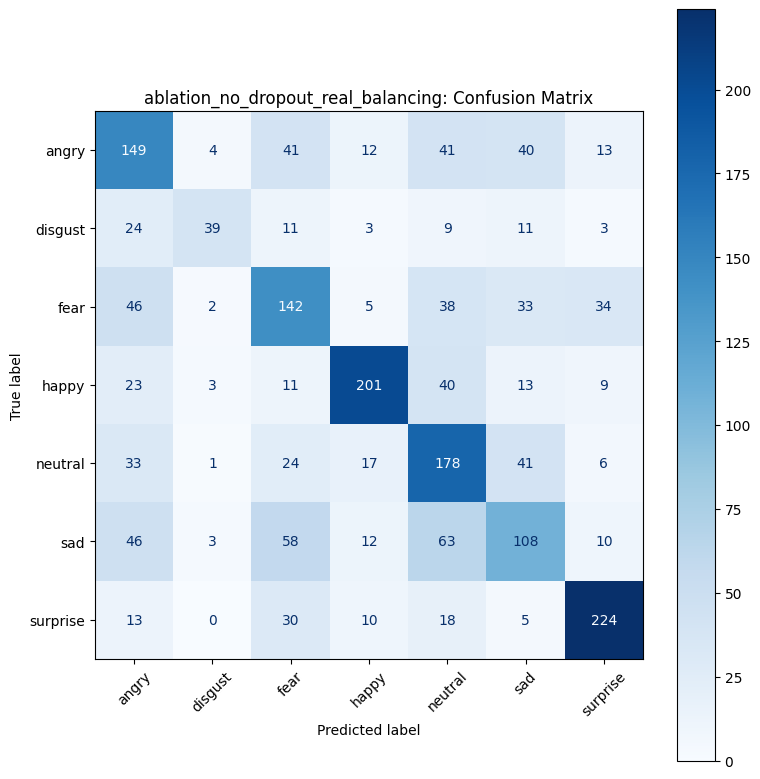

{'Model': 'ablation_no_dropout_real_balancing',
 'Test Loss': 2.3270323276519775,
 'Test Accuracy': 0.5478947162628174,
 'Macro F1': 0.5456372965975987,
 'Weighted F1': 0.5490561810039942}

In [ ]:
# Cell 21: Evaluate Ablation Model Without Dropout

best_ablation_path = os.path.join(
    results_dir,
    "ablation_no_dropout_real_balancing",
    "ablation_no_dropout_real_balancing_best.keras"
)

best_ablation_model = load_model(best_ablation_path)

ablation_result = evaluate_model(
    model=best_ablation_model,
    generator=test_generator,
    model_name="ablation_no_dropout_real_balancing"
)

ablation_result

## Creating Data Generators for Transfer Learning

This cell creates separate image generators for the transfer learning experiment.

DenseNet121 expects RGB images, so grayscale facial expression images are loaded in RGB format. The image size is also increased to 96 × 96 pixels to make the input more suitable for the pretrained model.

The training set still uses the balanced training folder, while validation and test sets remain unchanged.

In [ ]:
# Cell 22: Create Transfer Learning Generators for DenseNet121
# DenseNet121 expects RGB input, so images are loaded as RGB.
# The image size is increased to 96x96 to reduce training cost while still using transfer learning.

TRANSFER_IMG_SIZE = (96, 96)
TRANSFER_BATCH_SIZE = 32

transfer_train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

transfer_val_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

transfer_train_generator = transfer_train_datagen.flow_from_directory(
    balanced_train_dir,
    target_size=TRANSFER_IMG_SIZE,
    color_mode="rgb",
    batch_size=TRANSFER_BATCH_SIZE,
    class_mode="categorical",
    shuffle=True,
    seed=SEED
)

transfer_validation_generator = transfer_val_test_datagen.flow_from_directory(
    validation_dir,
    target_size=TRANSFER_IMG_SIZE,
    color_mode="rgb",
    batch_size=TRANSFER_BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

transfer_test_generator = transfer_val_test_datagen.flow_from_directory(
    test_dir,
    target_size=TRANSFER_IMG_SIZE,
    color_mode="rgb",
    batch_size=TRANSFER_BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

print("Transfer learning train batches:", len(transfer_train_generator))
print("Transfer learning validation batches:", len(transfer_validation_generator))
print("Transfer learning test batches:", len(transfer_test_generator))

Found 27929 images belonging to 7 classes.
Found 7066 images belonging to 7 classes.
Found 1900 images belonging to 7 classes.
Transfer learning train batches: 873
Transfer learning validation batches: 221
Transfer learning test batches: 60


## Building DenseNet121 Feature Extraction Model

This cell builds a transfer learning model using DenseNet121 pretrained on ImageNet.

In the feature extraction stage, the DenseNet121 convolutional base is frozen. This means the pretrained layers keep their ImageNet-learned features, and only the newly added classification layers are trained on the facial expression dataset.

The original ImageNet classification head is removed and replaced with a new output layer containing seven neurons for the seven emotion classes.

In [ ]:
# Cell 23: Build DenseNet121 Feature Extraction Model
# The pretrained convolutional base is frozen.
# Only the newly added classifier head is trained first.

def build_densenet_feature_extractor(input_shape=(96, 96, 3), num_classes=7):
    base_model = DenseNet121(
        weights="imagenet",
        include_top=False,
        input_shape=input_shape
    )

    base_model.trainable = False

    inputs = tf.keras.Input(shape=input_shape)
    x = base_model(inputs, training=False)

    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation="relu")(x)
    x = BatchNormalization()(x)
    x = Dropout(0.50)(x)

    x = Dense(128, activation="relu")(x)
    x = Dropout(0.30)(x)

    outputs = Dense(num_classes, activation="softmax")(x)

    model = Model(inputs, outputs, name="DenseNet121_Feature_Extraction_Real_Balancing")

    model.compile(
        optimizer=Adam(learning_rate=0.0003),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


densenet_model = build_densenet_feature_extractor(
    input_shape=(TRANSFER_IMG_SIZE[0], TRANSFER_IMG_SIZE[1], 3),
    num_classes=NUM_CLASSES
)

densenet_model.summary()

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "DenseNet121_Feature_Extraction_Real_Balancing"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 3, 3, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,334,727 (27.98 MB)

 Trainable params: 296,711 (1.13 MB)

 Non-trainable params: 7,038,016 (26.85 MB)

### DenseNet121 Feature Extraction Summary Interpretation

DenseNet121 is used as a pretrained feature extractor. The convolutional base has already learned general image patterns from ImageNet, such as edges, textures, and shapes.

A custom classification head is added on top of the pretrained model. Since the dataset has seven facial expression classes, the final dense layer uses seven neurons with softmax activation.

Freezing the base model reduces training cost and prevents the pretrained weights from changing too quickly.

## Training DenseNet121 Feature Extraction Model

This cell trains only the custom classification layers added on top of the frozen DenseNet121 base.

This stage is useful because it allows the model to learn how to map pretrained visual features to the seven facial expression classes without changing the original DenseNet121 weights.

The training time is recorded so that the transfer learning model can be compared with the CNN models trained from scratch.

Epoch 1/30


I0000 00:00:1778309141.669797    4405 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_297343__.289
I0000 00:00:1778309149.218258    4405 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


 21/873 ━━━━━━━━━━━━━━━━━━━━ 1:39 117ms/step - accuracy: 0.1185 - loss: 3.5735

I0000 00:00:1778309170.646391    4408 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_297343__.289


873/873 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - accuracy: 0.2503 - loss: 2.3131
Epoch 1: val_accuracy improved from None to 0.39386, saving model to real_sample_balancing_results/densenet121_feature_extraction_real_balancing/densenet121_feature_extraction_real_balancing_best.keras

Epoch 1: finished saving model to real_sample_balancing_results/densenet121_feature_extraction_real_balancing/densenet121_feature_extraction_real_balancing_best.keras
873/873 ━━━━━━━━━━━━━━━━━━━━ 226s 212ms/step - accuracy: 0.3018 - loss: 1.9957 - val_accuracy: 0.3939 - val_loss: 1.5709 - learning_rate: 3.0000e-04
Epoch 2/30
873/873 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.3798 - loss: 1.6647
Epoch 2: val_accuracy improved from 0.39386 to 0.41678, saving model to real_sample_balancing_results/densenet121_feature_extraction_real_balancing/densenet121_feature_extraction_real_balancing_best.keras

Epoch 2: finished saving model to real_sample_balancing_results/densenet121_feature_extraction_real_balancing/

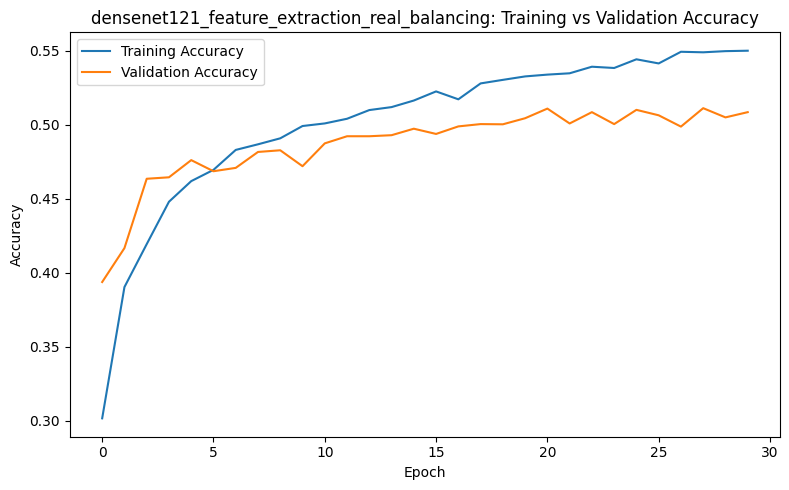

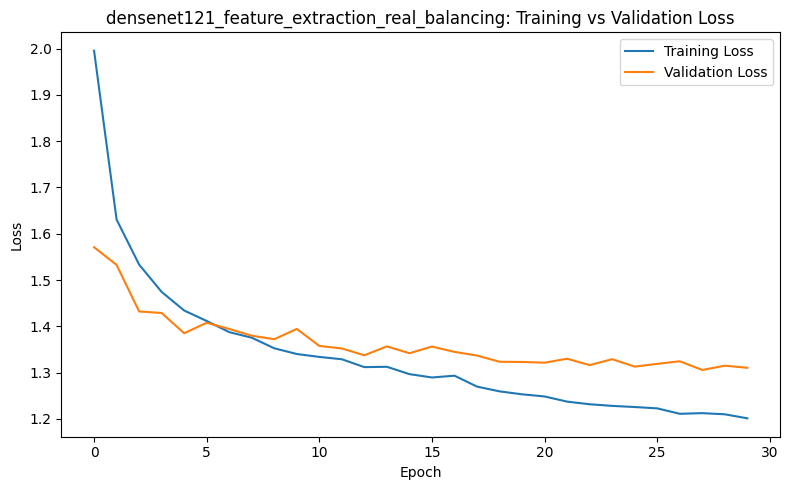

DenseNet121 feature extraction training time: 4041.06 seconds


In [ ]:
# Cell 24: Train DenseNet121 Feature Extraction Model
# This trains only the custom classification layers.

start_time = time.time()

densenet_history = densenet_model.fit(
    transfer_train_generator,
    validation_data=transfer_validation_generator,
    epochs=30,
    callbacks=get_callbacks("densenet121_feature_extraction_real_balancing"),
    verbose=1
)

densenet_training_time = time.time() - start_time

save_training_history(
    history=densenet_history,
    model_name="densenet121_feature_extraction_real_balancing",
    training_time=densenet_training_time
)

plot_training_history(
    history=densenet_history,
    model_name="densenet121_feature_extraction_real_balancing"
)

print(f"DenseNet121 feature extraction training time: {densenet_training_time:.2f} seconds")

## Preparing DenseNet121 for Fine-Tuning

This cell prepares the DenseNet121 model for fine-tuning by loading the best feature extraction model and unfreezing only the last few layers of the pretrained base.

Most of the DenseNet121 layers remain frozen, while the final layers are allowed to update. A very small learning rate is used because fine-tuning with a high learning rate may damage the pretrained weights.

Fine-tuning helps the pretrained model adjust more specifically to facial expression images.

In [ ]:
# Cell 25: Fine-Tune DenseNet121 Model
# A small number of top layers are unfrozen and trained with a low learning rate.
# This helps the model adapt to facial expression images without destroying pretrained features.

best_densenet_path = os.path.join(
    results_dir,
    "densenet121_feature_extraction_real_balancing",
    "densenet121_feature_extraction_real_balancing_best.keras"
)

fine_tune_model = load_model(best_densenet_path)

# Find the DenseNet base model inside the full model
base_model = None
for layer in fine_tune_model.layers:
    if "densenet" in layer.name.lower():
        base_model = layer
        break

if base_model is None:
    raise ValueError("DenseNet base model layer was not found.")

base_model.trainable = True

# Freeze most layers and fine-tune only the last part
for layer in base_model.layers[:-40]:
    layer.trainable = False

fine_tune_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

fine_tune_model.summary()

Model: "DenseNet121_Feature_Extraction_Real_Balancing"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 3, 3, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,334,727 (27.98 MB)

 Trainable params: 1,124,423 (4.29 MB)

 Non-trainable params: 6,210,304 (23.69 MB)

## Training the Fine-Tuned DenseNet121 Model

This cell trains the fine-tuned DenseNet121 model for a smaller number of epochs using a low learning rate.

The aim is to slightly adjust the high-level pretrained features to better match the facial expression classification task. Since the dataset contains small grayscale-style facial images, fine-tuning is tested to see whether transfer learning can improve over the custom CNN models.

Epoch 1/20


I0000 00:00:1778313234.547804    4406 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_506267__.333
E0000 00:00:1778313400.564500    4503 slow_operation_alarm.cc:73] 
********************************
[Compiling module a_inference_one_step_on_data_506267__.333 for GPU] Very slow compile? If you want to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
********************************
E0000 00:00:1778313500.630104    4406 slow_operation_alarm.cc:140] The operation took 3m40.078302078s

********************************
[Compiling module a_inference_one_step_on_data_506267__.333 for GPU] Very slow compile? If you want to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
********************************


765/873 ━━━━━━━━━━━━━━━━━━━━ 13s 128ms/step - accuracy: 0.4667 - loss: 1.4363

I0000 00:00:1778315230.806618    4405 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_506267__.333


873/873 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4679 - loss: 1.4322
Epoch 1: val_accuracy improved from None to 0.46136, saving model to real_sample_balancing_results/densenet121_finetuned_real_balancing/densenet121_finetuned_real_balancing_best.keras

Epoch 1: finished saving model to real_sample_balancing_results/densenet121_finetuned_real_balancing/densenet121_finetuned_real_balancing_best.keras
873/873 ━━━━━━━━━━━━━━━━━━━━ 2157s 2s/step - accuracy: 0.4777 - loss: 1.4005 - val_accuracy: 0.4614 - val_loss: 1.4319 - learning_rate: 1.0000e-05
Epoch 2/20
873/873 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.5056 - loss: 1.3232
Epoch 2: val_accuracy improved from 0.46136 to 0.47354, saving model to real_sample_balancing_results/densenet121_finetuned_real_balancing/densenet121_finetuned_real_balancing_best.keras

Epoch 2: finished saving model to real_sample_balancing_results/densenet121_finetuned_real_balancing/densenet121_finetuned_real_balancing_best.keras
873/873 ━━━━━━━━━━━━

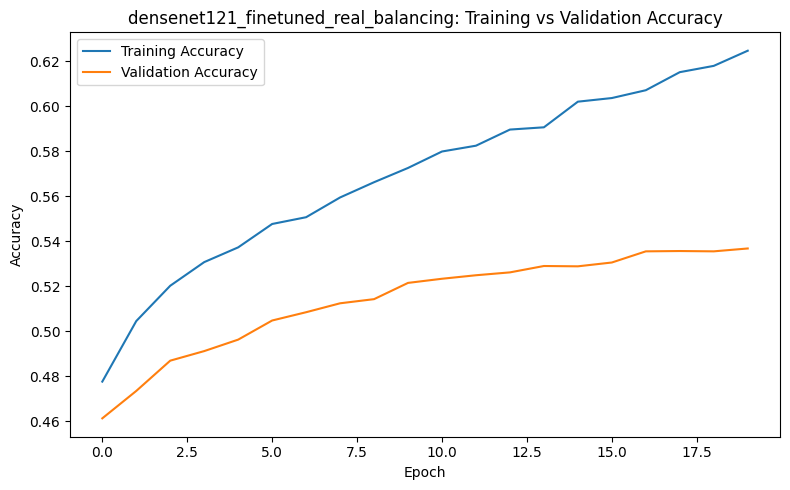

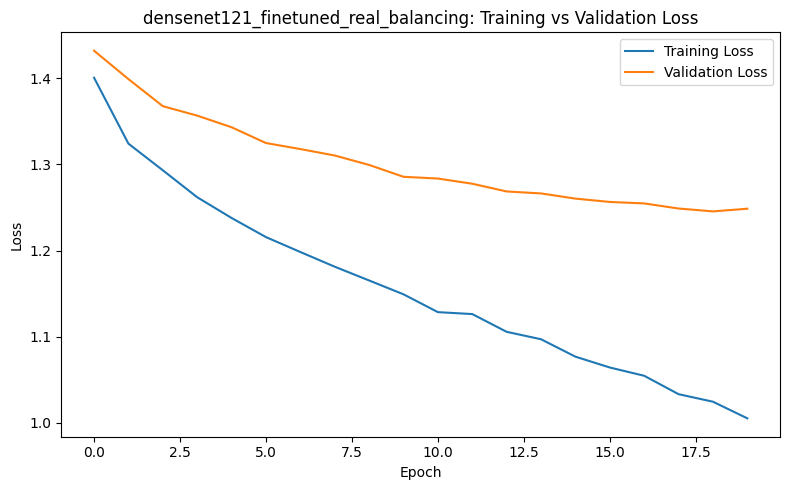

DenseNet121 fine-tuning training time: 4710.79 seconds


In [ ]:
# Cell 26: Train Fine-Tuned DenseNet121 Model
# Fine-tuning is done for fewer epochs with a low learning rate.

start_time = time.time()

fine_tune_history = fine_tune_model.fit(
    transfer_train_generator,
    validation_data=transfer_validation_generator,
    epochs=20,
    callbacks=get_callbacks("densenet121_finetuned_real_balancing"),
    verbose=1
)

fine_tune_training_time = time.time() - start_time

save_training_history(
    history=fine_tune_history,
    model_name="densenet121_finetuned_real_balancing",
    training_time=fine_tune_training_time
)

plot_training_history(
    history=fine_tune_history,
    model_name="densenet121_finetuned_real_balancing"
)

print(f"DenseNet121 fine-tuning training time: {fine_tune_training_time:.2f} seconds")

## Evaluating the Fine-Tuned DenseNet121 Model

This cell evaluates the fine-tuned DenseNet121 model on the test set using the same metrics as the CNN models from scratch.

The result is compared with the baseline CNN, deeper CNN, SGD model, and ablation model. This helps determine whether transfer learning was more effective than training a custom CNN from scratch for this dataset.

60/60 ━━━━━━━━━━━━━━━━━━━━ 42s 508ms/step - accuracy: 0.4963 - loss: 1.3379
60/60 ━━━━━━━━━━━━━━━━━━━━ 24s 278ms/step

densenet121_finetuned_real_balancing Test Loss: 1.3379
densenet121_finetuned_real_balancing Test Accuracy: 0.4963

Classification Report:
              precision    recall  f1-score   support

       angry       0.42      0.42      0.42       300
     disgust       0.29      0.23      0.26       100
        fear       0.42      0.27      0.33       300
       happy       0.63      0.72      0.67       300
     neutral       0.45      0.56      0.50       300
         sad       0.37      0.37      0.37       300
    surprise       0.69      0.72      0.70       300

    accuracy                           0.50      1900
   macro avg       0.47      0.47      0.47      1900
weighted avg       0.49      0.50      0.49      1900



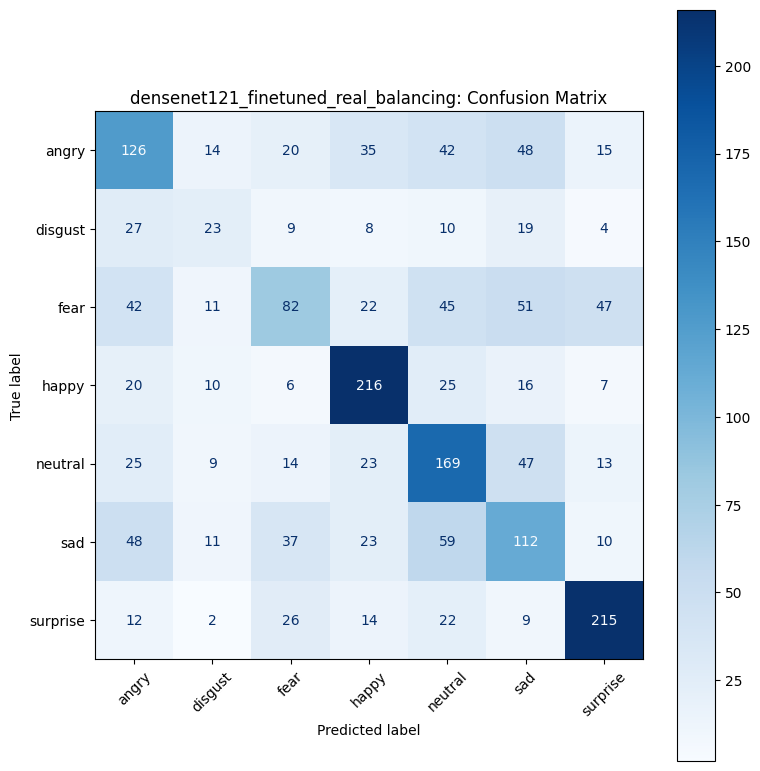

{'Model': 'densenet121_finetuned_real_balancing',
 'Test Loss': 1.33786141872406,
 'Test Accuracy': 0.49631577730178833,
 'Macro F1': 0.46575997908849837,
 'Weighted F1': 0.48788676051301866}

In [ ]:
# Cell 27: Evaluate Fine-Tuned DenseNet121 Model

best_finetuned_path = os.path.join(
    results_dir,
    "densenet121_finetuned_real_balancing",
    "densenet121_finetuned_real_balancing_best.keras"
)

best_finetuned_model = load_model(best_finetuned_path)

transfer_result = evaluate_model(
    model=best_finetuned_model,
    generator=transfer_test_generator,
    model_name="densenet121_finetuned_real_balancing"
)

transfer_result

## Final Comparison of All Models

This cell compares the performance of all trained models in one table.

The models are compared using:

- test loss
- test accuracy
- macro F1-score
- weighted F1-score

Weighted F1-score is useful because it considers class support and gives a balanced view of performance when the dataset has class imbalance. The final bar chart makes it easier to visually compare the test accuracy of each model.

From the results, the deeper CNN with Adam achieved the best overall performance among the tested models.

Final model comparison:
                               Model  Test Loss  Test Accuracy  Macro F1  Weighted F1
      deeper_cnn_adam_real_balancing   1.243374       0.602105  0.590556     0.600790
       deeper_cnn_sgd_real_balancing   1.185777       0.590526  0.574947     0.585854
  ablation_no_dropout_real_balancing   2.327032       0.547895  0.545637     0.549056
         baseline_cnn_real_balancing   1.422395       0.502632  0.483255     0.494323
densenet121_finetuned_real_balancing   1.337861       0.496316  0.465760     0.487887


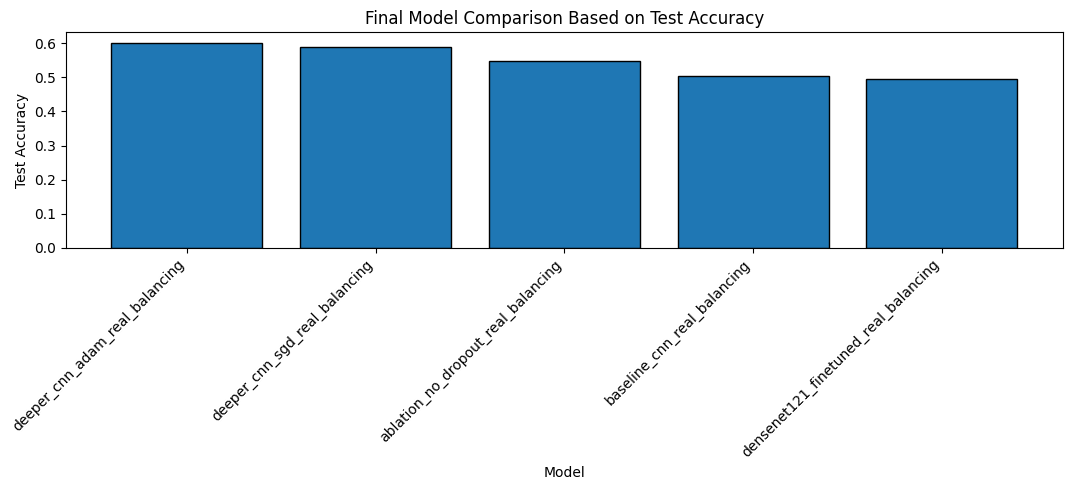

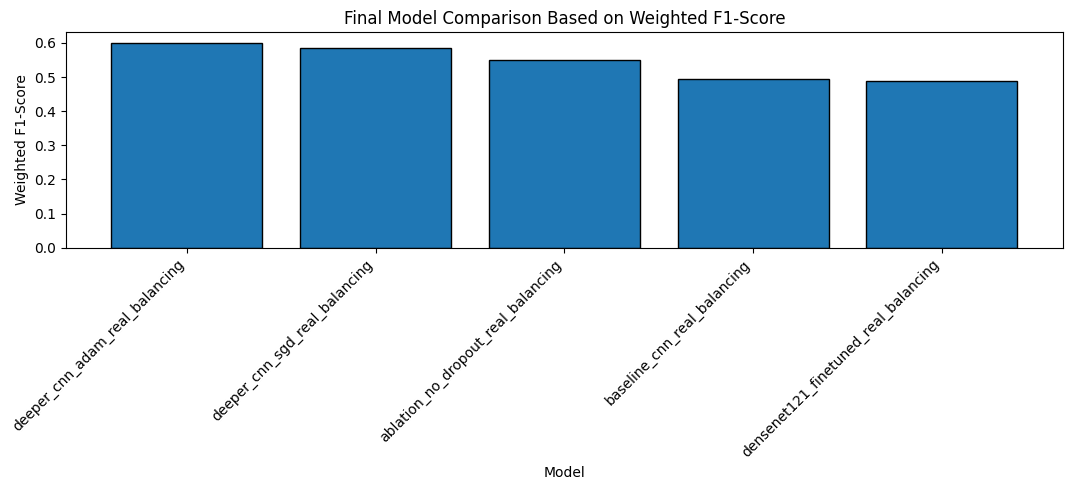

In [ ]:
# Cell 28: Compare All Model Results
# This table is useful for the final report.

all_results = [
    baseline_result,
    deeper_adam_result,
    deeper_sgd_result,
    ablation_result,
    transfer_result
]

results_df = pd.DataFrame(all_results)

results_df = results_df.sort_values(
    by="Weighted F1",
    ascending=False
).reset_index(drop=True)

results_path = os.path.join(results_dir, "final_model_comparison.csv")
results_df.to_csv(results_path, index=False)

print("Final model comparison:")
print(results_df.to_string(index=False))

plt.figure(figsize=(11, 5))
plt.bar(results_df["Model"], results_df["Test Accuracy"], edgecolor="black")
plt.title("Final Model Comparison Based on Test Accuracy")
plt.xlabel("Model")
plt.ylabel("Test Accuracy")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(11, 5))
plt.bar(results_df["Model"], results_df["Weighted F1"], edgecolor="black")
plt.title("Final Model Comparison Based on Weighted F1-Score")
plt.xlabel("Model")
plt.ylabel("Weighted F1-Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Final Result Observation

The deeper CNN trained with Adam achieved the highest test accuracy and weighted F1-score. This shows that increasing model depth and adding regularization helped improve performance compared with the baseline CNN.

The SGD model also performed reasonably well, but Adam gave slightly better results. The ablation model performed worse than the regularized deeper CNN, which suggests that Dropout helped the model generalize better.

DenseNet121 transfer learning did not outperform the best custom CNN. This may be because DenseNet121 was pretrained on ImageNet RGB images, while this dataset contains small facial expression images. Therefore, the custom CNN trained directly on grayscale facial images was more suitable for this task.

## Performing Prediction on Random Test Images

This cell displays random test images with their actual and predicted labels.

This is useful because numerical metrics alone do not fully explain how the model behaves. By viewing sample predictions, it becomes easier to understand whether the model is making reasonable predictions and where it may be confused.

1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step


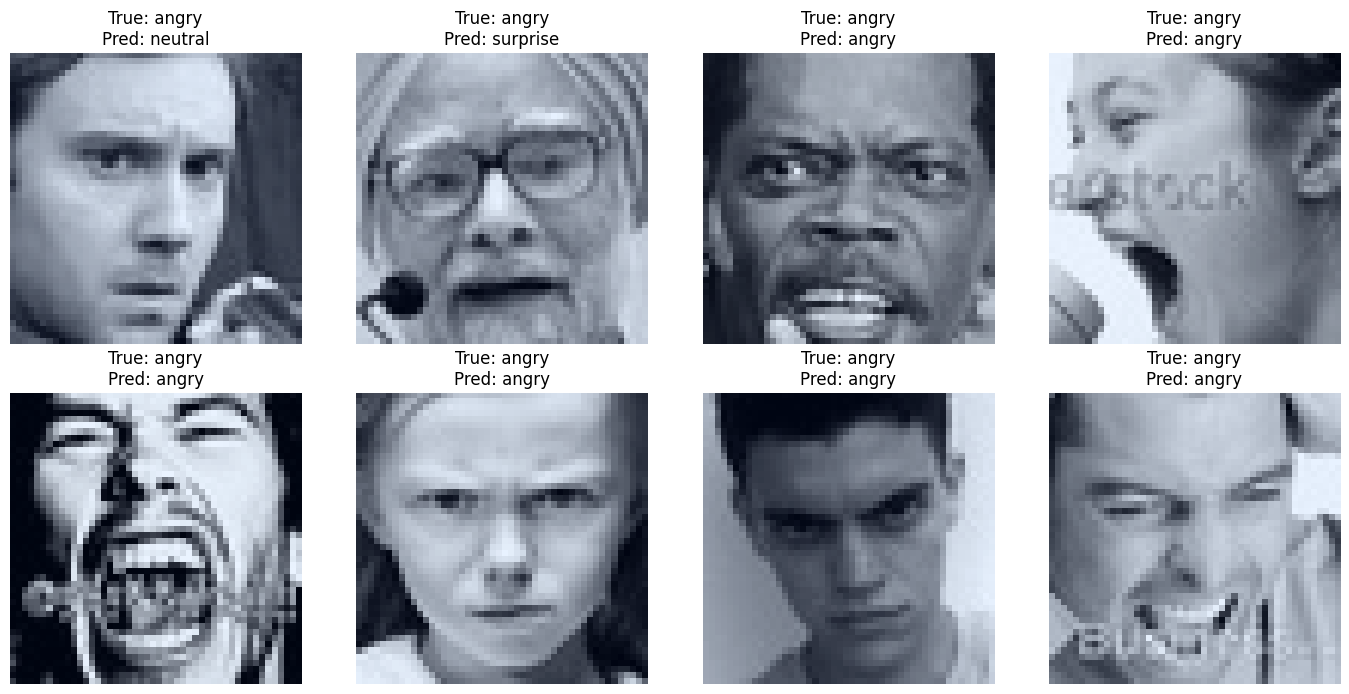

In [ ]:
# Cell 29: Predict Random Test Images
# This shows model predictions on real test images.

def show_random_predictions(model, generator, class_names, number_of_images=8):
    generator.reset()

    images, labels = next(generator)
    predictions = model.predict(images)

    predicted_classes = np.argmax(predictions, axis=1)
    true_classes = np.argmax(labels, axis=1)

    plt.figure(figsize=(14, 7))

    for i in range(min(number_of_images, len(images))):
        plt.subplot(2, 4, i + 1)

        image = images[i]

        # For grayscale images
        if image.shape[-1] == 1:
            plt.imshow(image.squeeze(), cmap="gray")
        else:
            # For preprocessed RGB images, display roughly by clipping
            display_image = image.copy()
            display_image = display_image - display_image.min()
            display_image = display_image / (display_image.max() + 1e-8)
            plt.imshow(display_image)

        true_label = class_names[true_classes[i]]
        predicted_label = class_names[predicted_classes[i]]

        plt.title(f"True: {true_label}\nPred: {predicted_label}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()


# Transfer-learning sample prediction
show_random_predictions(
    model=best_finetuned_model,
    generator=transfer_test_generator,
    class_names=CLASS_NAMES,
    number_of_images=8
)

## Summary Notes for Report Writing

This cell prints the main points that can be used in the final report.

The notes summarize the key decisions made in the notebook, including real-sample balancing, model design, optimizer comparison, ablation study, transfer learning, GPU usage, and final model selection.

These points are useful for writing the methodology, experiment, result discussion, and conclusion sections of the report.

In [ ]:
# Cell 30: Final Notes for Report
# This prints short points that can be used while writing the report.

print("""
Report points:

1. This notebook used real-sample balancing instead of synthetic augmentation.
2. Majority classes were reduced to a fixed target count.
3. Minority classes were improved by adding extra real images where available.
4. Validation and test sets were not changed, so evaluation remained fair.
5. Baseline CNN was trained first as a simple reference model.
6. A deeper CNN with Batch Normalization and Dropout was trained to improve feature learning.
7. Adam and SGD optimizers were compared using the same deeper architecture.
8. An ablation model without Dropout was trained to study the effect of regularization.
9. DenseNet121 transfer learning was tested using feature extraction and fine-tuning.
10. Final comparison used accuracy, macro F1, weighted F1, confusion matrix, and classification report.
""")


Report points:

1. This notebook used real-sample balancing instead of synthetic augmentation.
2. Majority classes were reduced to a fixed target count.
3. Minority classes were improved by adding extra real images where available.
4. Validation and test sets were not changed, so evaluation remained fair.
5. Baseline CNN was trained first as a simple reference model.
6. A deeper CNN with Batch Normalization and Dropout was trained to improve feature learning.
7. Adam and SGD optimizers were compared using the same deeper architecture.
8. An ablation model without Dropout was trained to study the effect of regularization.
9. DenseNet121 transfer learning was tested using feature extraction and fine-tuning.
10. Final comparison used accuracy, macro F1, weighted F1, confusion matrix, and classification report.



## Hardware and Training Setup Summary

This cell records the main training setup used in the experiment.

It includes image size, batch size, number of classes, target images per class, transfer learning image size, and whether GPU acceleration was used.

This information is important for the computational efficiency section of the report because training time and hardware availability affect how practical each model is.

In [ ]:
# Cell 31: Hardware and Training Setup Summary
# This cell records whether GPU acceleration was available.
# It is useful for the report section on computational efficiency.

gpu_devices = tf.config.list_physical_devices("GPU")

if len(gpu_devices) > 0:
    hardware_used = "GPU acceleration was available and used during training."
else:
    hardware_used = "No GPU was detected. Training was performed using CPU."

setup_summary = {
    "Image Size for CNN Models": IMG_SIZE,
    "Batch Size for CNN Models": BATCH_SIZE,
    "Image Size for Transfer Learning": TRANSFER_IMG_SIZE,
    "Batch Size for Transfer Learning": TRANSFER_BATCH_SIZE,
    "Target Images Per Class": TARGET_PER_CLASS,
    "Number of Classes": NUM_CLASSES,
    "Classes": CLASS_NAMES,
    "Hardware Used": hardware_used
}

setup_summary_path = os.path.join(results_dir, "hardware_and_training_setup_summary.json")

with open(setup_summary_path, "w") as file:
    json.dump(setup_summary, file, indent=4)

print("Hardware and training setup summary:")
for key, value in setup_summary.items():
    print(f"{key}: {value}")

Hardware and training setup summary:
Image Size for CNN Models: (48, 48)
Batch Size for CNN Models: 64
Image Size for Transfer Learning: (96, 96)
Batch Size for Transfer Learning: 32
Target Images Per Class: 4000
Number of Classes: 7
Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Hardware Used: GPU acceleration was available and used during training.


## Error Analysis Using Misclassified Images

This cell displays examples of images that were incorrectly classified by the best model.

Error analysis is important because it helps explain the limitations of the model. Some facial expressions can look visually similar, such as fear and surprise or sad and neutral. Low image quality, unclear facial expressions, and class imbalance can also make classification difficult.

By studying misclassified images, it becomes easier to understand why the model made mistakes and what improvements could be made in future work.

30/30 ━━━━━━━━━━━━━━━━━━━━ 8s 253ms/step
Total test images: 1900
Total misclassified images: 756


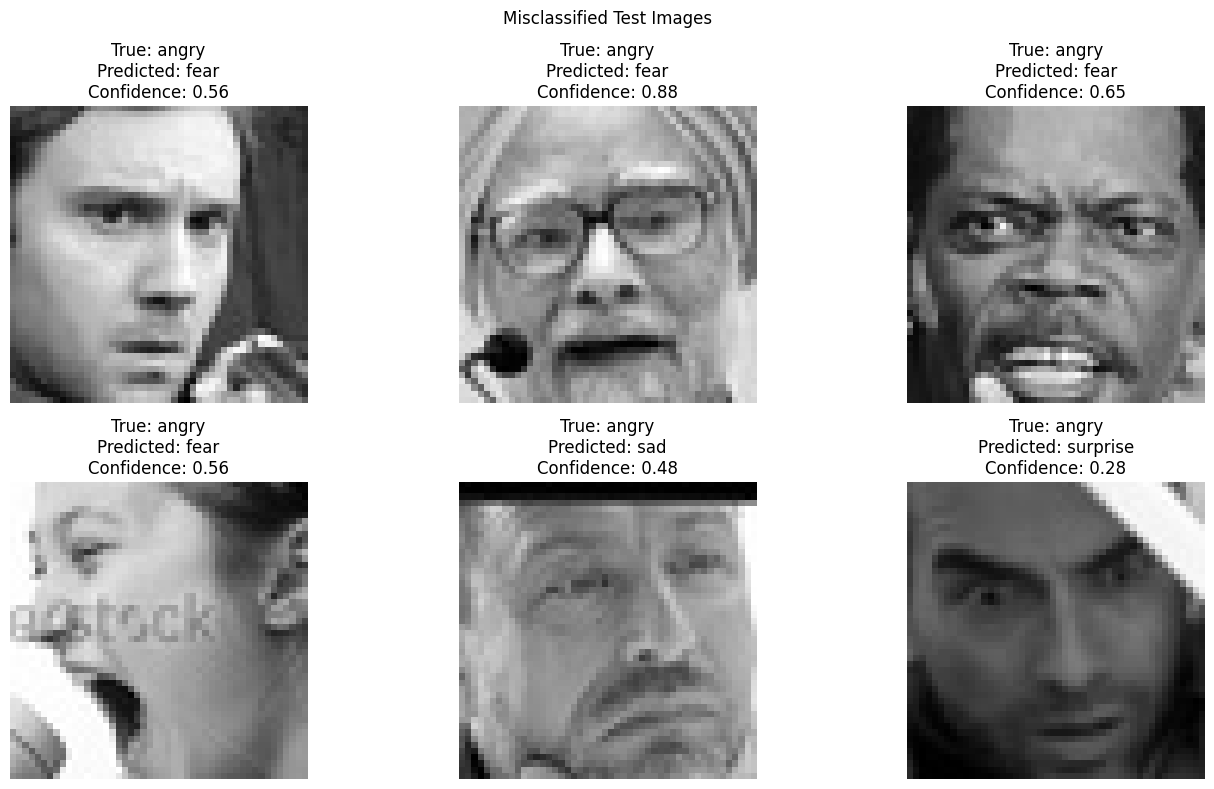

In [ ]:
# Cell 32: Error Analysis With Misclassified Images
# This cell displays wrongly classified test images.
# It helps explain model weaknesses in the report and viva.

def show_misclassified_images(model, generator, class_names, number_of_images=6):
    generator.reset()

    all_predictions = model.predict(generator, verbose=1)
    predicted_classes = np.argmax(all_predictions, axis=1)
    true_classes = generator.classes

    wrong_indices = np.where(predicted_classes != true_classes)[0]

    print(f"Total test images: {len(true_classes)}")
    print(f"Total misclassified images: {len(wrong_indices)}")

    if len(wrong_indices) == 0:
        print("No misclassified images found.")
        return

    selected_indices = wrong_indices[:number_of_images]

    plt.figure(figsize=(14, 8))

    for plot_index, image_index in enumerate(selected_indices):
        image_path = generator.filepaths[image_index]

        image = Image.open(image_path)

        plt.subplot(2, 3, plot_index + 1)
        plt.imshow(image, cmap="gray")

        true_label = class_names[true_classes[image_index]]
        predicted_label = class_names[predicted_classes[image_index]]
        confidence = np.max(all_predictions[image_index])

        plt.title(
            f"True: {true_label}\nPredicted: {predicted_label}\nConfidence: {confidence:.2f}"
        )
        plt.axis("off")

    plt.suptitle("Misclassified Test Images")
    plt.tight_layout()
    plt.show()


# For scratch CNN models, use test_generator.
# Here, the best deeper Adam model is used for error analysis.
show_misclassified_images(
    model=best_deeper_adam_model,
    generator=test_generator,
    class_names=CLASS_NAMES,
    number_of_images=6
)

## Sample Prediction Using the Best Scratch CNN Model

This cell performs sample prediction using the best CNN model trained from scratch.

The deeper CNN with Adam is used because it achieved the best overall performance in the final comparison. This prediction output supports the inference requirement of the assessment and shows how the trained model performs on unseen test images.

2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step


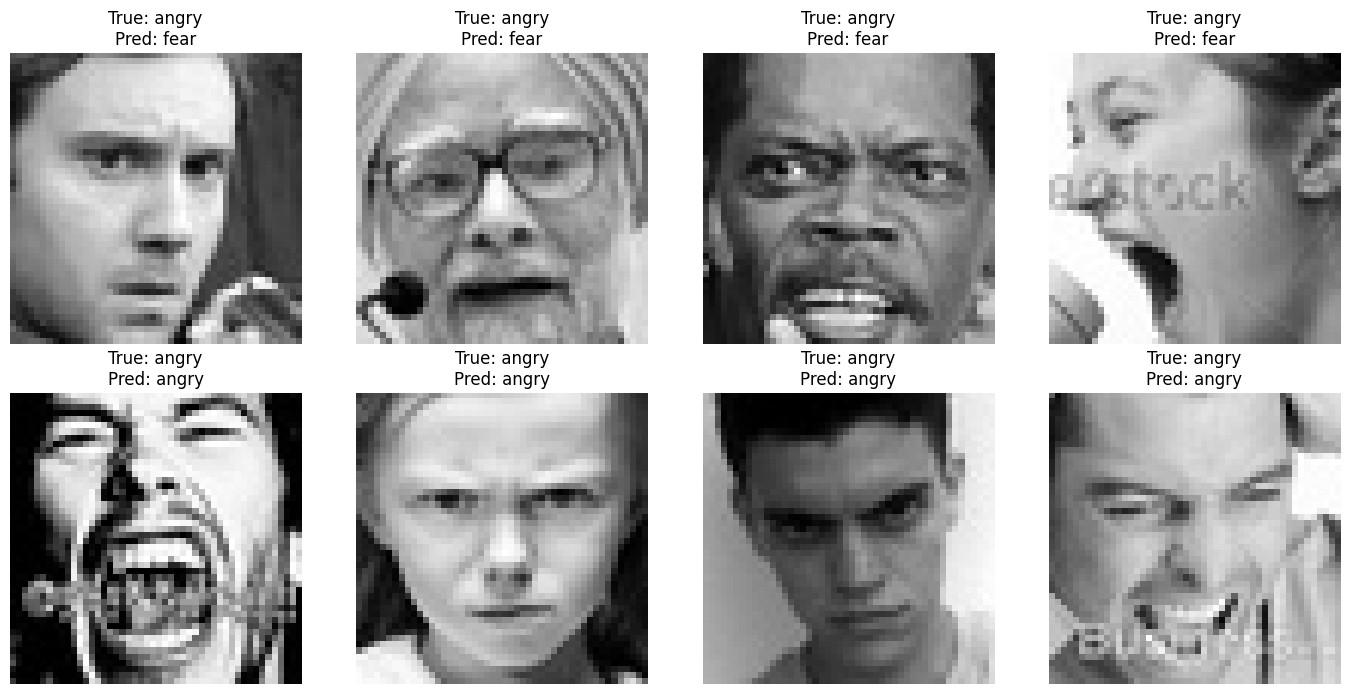

In [ ]:
# Cell 33: Sample Prediction Using Best Scratch CNN Model
# This is added because Part A asks for inference on sample images.
# It uses the best deeper CNN trained from scratch.

show_random_predictions(
    model=best_deeper_adam_model,
    generator=test_generator,
    class_names=CLASS_NAMES,
    number_of_images=8
)

## Final code checklist

- Dataset distribution is counted and visualized.
- Real-sample training balance is created.
- Validation and test folders are unchanged.
- Data generators are prepared.
- Baseline CNN is trained and evaluated.
- Deeper CNN with Batch Normalization and Dropout is trained and evaluated.
- Adam and SGD are compared.
- Ablation study without Dropout is included.
- DenseNet121 transfer learning is included.
- Feature extraction and fine-tuning are both included.
- Training time, GPU availability, classification reports, confusion matrices, and final comparison table are saved.
- Sample predictions and misclassified examples are shown.